01_data_preparation

02_feature_extraction_and_ml_traning

03_acoustic_DL

04_linguistic_DL

05_image_DL

# Check CPU/GPU/Memory

In [1]:
# In order to use a GPU with this notebook, select the Runtime > Change runtime type menu and then set the hardware accelerator
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Jun 12 09:18:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# If the execution result of running the code cell below is 'Not using a high-RAM runtime',
# then we can enable a high-RAM runtime via Runtime > Change runtime type in the menu.
# Then select High-RAM in the Runtime shape toggle button

import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 56.9 gigabytes of available RAM

You are using a high-RAM runtime!


# Imports

In [ ]:
!pip install google-cloud-storage matplotlib scikit-learn xgboost lightgbm 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 51.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 34.7 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=85dacd7e4386db7652beb84c1fd4d8b9e2ee5aed781fc107445c970d9be4b95d
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [5]:
# ML Model imports
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Configurations

In [ ]:
from google.colab import auth
auth.authenticate_user()

# To find the credentials automatically
from google.cloud import storage
client = storage.Client(project=GCP_PROJECT_ID) # GCP Project ID


In [ ]:
# Initialize GCP Storage
client = storage.Client()
bucket_name = VOICE_DATA_BUCKET_NAME # GCP Storage bucket name
bucket = client.get_bucket(bucket_name)
print(f"Bucket {bucket.name} successfully loaded.")

Bucket voicedata-bucket successfully loaded.


In [8]:

print(os.getcwd())

/content


In [9]:
# Configuration
CATEGORIES = ['CN', 'AD']
feature_mode = "librosa"
local_base_path = f"local_data/features/{feature_mode}"

# Ensure local directories exist for processing
os.makedirs(local_base_path, exist_ok=True)

# Download the processed data from GCP

In [10]:
# Helper function to download features from GCS
def download_feature_from_gcs(gcs_path, local_filename):
    blob = bucket.blob(gcs_path)
    local_full_path = os.path.join(local_base_path, local_filename)
    # Only download if it doesn't already exist locally
    if not os.path.exists(local_full_path):
        print(f"Downloading {local_filename}...")
        blob.download_to_filename(local_full_path)
    return local_full_path

In [11]:
print("--- Downloading Extracted Features from GCS ---")

# Define the splits
addresso_splits = ["X_train", "X_val", "X_test"]
wls_splits = ["X_wls"]

# 1. Download ADDReSSo Features
for split in addresso_splits:
    download_feature_from_gcs(f"ADDReSS2021/features/{feature_mode}/{split}_audio.csv", f"{split}_audio.csv")
    download_feature_from_gcs(f"ADDReSS2021/features/{feature_mode}/{split}_labels.csv", f"{split}_labels.csv")
    download_feature_from_gcs(f"ADDReSS2021/features/{feature_mode}/{split}_text.npy", f"{split}_text.npy")

# 2. Download WLS Features
for split in wls_splits:
    download_feature_from_gcs(f"WLS/features/{feature_mode}/{split}_audio.csv", f"{split}_audio.csv")
    download_feature_from_gcs(f"WLS/features/{feature_mode}/{split}_labels.csv", f"{split}_labels.csv")
    download_feature_from_gcs(f"WLS/features/{feature_mode}/{split}_text.npy", f"{split}_text.npy")

--- Downloading Extracted Features from GCS ---


In [12]:
print("\n--- Loading Features into Memory ---")

# Load Pandas DataFrames (Acoustic)
# index_col=0 ensures we keep the audio paths as the index, preventing "Unnamed: 0" columns
X_train_audio = pd.read_csv(f"{local_base_path}/X_train_audio.csv", index_col=0)
X_val_audio   = pd.read_csv(f"{local_base_path}/X_val_audio.csv", index_col=0)
X_test_audio  = pd.read_csv(f"{local_base_path}/X_test_audio.csv", index_col=0)
X_wls_audio   = pd.read_csv(f"{local_base_path}/X_wls_audio.csv", index_col=0)

# Load Labels
# index_col=0 keeps the alignment index, squeeze() turns the DataFrame back into a 1D Pandas Series
y_train = pd.read_csv(f"{local_base_path}/X_train_labels.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{local_base_path}/X_val_labels.csv", index_col=0).squeeze()
y_test  = pd.read_csv(f"{local_base_path}/X_test_labels.csv", index_col=0).squeeze()
y_wls   = pd.read_csv(f"{local_base_path}/X_wls_labels.csv", index_col=0).squeeze()

# Load NumPy Arrays (Linguistic)
X_train_text = np.load(f"{local_base_path}/X_train_text.npy")
X_val_text   = np.load(f"{local_base_path}/X_val_text.npy")
X_test_text  = np.load(f"{local_base_path}/X_test_text.npy")
X_wls_text   = np.load(f"{local_base_path}/X_wls_text.npy")


--- Loading Features into Memory ---


In [13]:
print("Success! All acoustic features, linguistic features, and labels have been loaded.")
print("-" * 50)
print(f"X_train_audio shape: {X_train_audio.shape} | X_train_text shape: {X_train_text.shape}")
print(f"X_val_audio shape:   {X_val_audio.shape} | X_val_text shape:   {X_val_text.shape}")
print(f"X_test_audio shape:  {X_test_audio.shape} | X_test_text shape:  {X_test_text.shape}")
print(f"X_wls_audio shape:   {X_wls_audio.shape} | X_wls_text shape:   {X_wls_text.shape}")

Success! All acoustic features, linguistic features, and labels have been loaded.
--------------------------------------------------
X_train_audio shape: (112, 160) | X_train_text shape: (112, 1000)
X_val_audio shape:   (24, 160) | X_val_text shape:   (24, 1000)
X_test_audio shape:  (25, 160) | X_test_text shape:  (25, 1000)
X_wls_audio shape:   (40, 160) | X_wls_text shape:   (40, 1000)


# ML Model Training - Acoustic

# Scale dataset

In [14]:
from sklearn.preprocessing import StandardScaler

# Scale the acoustic features
scaler = StandardScaler()

# Fit ONLY on the training data to prevent data leakage
X_train_audio_scaled = scaler.fit_transform(X_train_audio)

# Transform Validation, Testing, and WLS sets
X_val_audio_scaled = scaler.transform(X_val_audio)
X_test_audio_scaled = scaler.transform(X_test_audio)
X_wls_audio_scaled = scaler.transform(X_wls_audio)

# Label Encoding

In [15]:
# XGBoost model requires target labels to be numeric,
# so a LabelEncoder is used to map 'AD' and 'CN' labels to 1 and 0.

from sklearn.preprocessing import LabelEncoder

# Create a custom encoder to explicitly force CN=0 and AD=1, overriding Scikit-learn's default LabelEncoder() alphabetical sorting
class ExplicitLabelEncoder:
    def __init__(self):
        self.map_to_int = {'CN': 0, 'AD': 1}
        self.map_to_str = {0: 'CN', 1: 'AD'}

    def fit_transform(self, y):
        return np.array([self.map_to_int[val] for val in y])

    def transform(self, y):
        return np.array([self.map_to_int[val] for val in y])

    def inverse_transform(self, y):
        return np.array([self.map_to_str[val] for val in y])

# Initialize our explicit encoder
le = ExplicitLabelEncoder()

# Fit/Transform the labels
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)
y_wls_encoded = le.transform(y_wls)

print("Success! Labels explicitly encoded: CN = 0, AD = 1.")

Success! Labels explicitly encoded: CN = 0, AD = 1.


### Evaluation Method

In [16]:
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_clinical_model(model_name, dataset_name, y_true, y_pred, y_proba=None, pos_label='AD'):
    """
    Calculates comprehensive diagnostic metrics and plots a confusion matrix.
    pos_label is the target condition of interest (e.g., 'AD').
    """
    print(f"\n{'='*60}")
    print(f"  Evaluating: {model_name} | Dataset: {dataset_name}")
    print(f"{'='*60}")

    # Calculate metrics targeting the positive label
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label)
    sens = recall_score(y_true, y_pred, pos_label=pos_label) # Sensitivity / Recall
    f1 = f1_score(y_true, y_pred, pos_label=pos_label)

    # Calculate Specificity from the Confusion Matrix
    neg_label = 'CN' if pos_label == 'AD' else 'AD'
    cm = confusion_matrix(y_true, y_pred, labels=[pos_label, neg_label])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Sensitivity: {sens:.4f}")   # (True Positive Rate: detecting AD)
    print(f"Specificity: {spec:.4f}")   # (True Negative Rate: correctly identifying CN)
    print(f"F1-Score:    {f1:.4f}")

    # Calculate ROC-AUC if probabilities are provided
    if y_proba is not None:
        # Convert string labels to binary for the AUC calculation (1 for AD, 0 for CN)
        y_true_bin = np.array([1 if y == pos_label else 0 for y in y_true])
        auc = roc_auc_score(y_true_bin, y_proba)
        print(f"ROC-AUC:     {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 60)

    # Plot Visual Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[pos_label, neg_label])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    # Updated title to include the dataset name
    plt.title(f"{model_name} Confusion Matrix\n({dataset_name})")
    plt.show()

    # --- Return metrics for the summary table ---
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": acc,
        "Precision": prec,
        "Sensitivity": sens,
        "Specificity": spec,
        "F1-Score": f1,
        "ROC-AUC": auc
    }

In [20]:
# Create a master list to store metrics from all models and datasets
global_summary_metrics = []

##1. Training - Acoustic ML models

--- Training and Evaluating Acoustic Models ---

  Evaluating: SVM | Dataset: ADDReSSo Val
Accuracy:    0.5417
Precision:   0.5625
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6207
ROC-AUC:     0.6993

Classification Report:
              precision    recall  f1-score   support

          AD       0.56      0.69      0.62        13
          CN       0.50      0.36      0.42        11

    accuracy                           0.54        24
   macro avg       0.53      0.53      0.52        24
weighted avg       0.53      0.54      0.53        24

------------------------------------------------------------


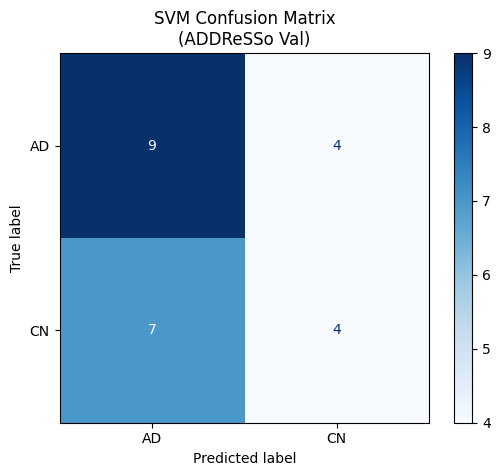


  Evaluating: SVM | Dataset: ADDReSSo Test
Accuracy:    0.6000
Precision:   0.5714
Sensitivity: 0.9231
Specificity: 0.9231
F1-Score:    0.7059
ROC-AUC:     0.5705

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.92      0.71        13
          CN       0.75      0.25      0.38        12

    accuracy                           0.60        25
   macro avg       0.66      0.59      0.54        25
weighted avg       0.66      0.60      0.55        25

------------------------------------------------------------


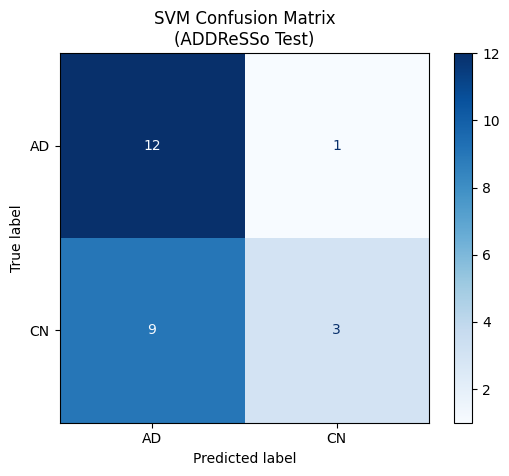


  Evaluating: SVM | Dataset: WLS External
Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 1.0000
Specificity: 1.0000
F1-Score:    0.6667
ROC-AUC:     0.5950

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      1.00      0.67        20
          CN       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40

------------------------------------------------------------


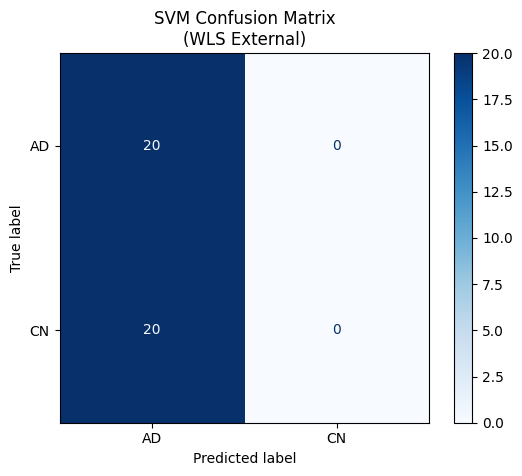


  Evaluating: Logistic Regression | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.7000
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6087
ROC-AUC:     0.6084

Classification Report:
              precision    recall  f1-score   support

          AD       0.70      0.54      0.61        13
          CN       0.57      0.73      0.64        11

    accuracy                           0.62        24
   macro avg       0.64      0.63      0.62        24
weighted avg       0.64      0.62      0.62        24

------------------------------------------------------------


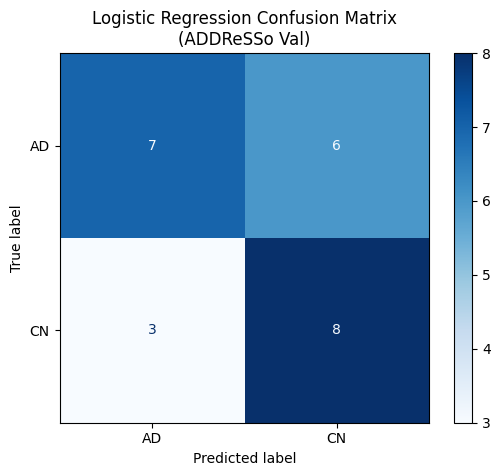


  Evaluating: Logistic Regression | Dataset: ADDReSSo Test
Accuracy:    0.5200
Precision:   0.5294
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6000
ROC-AUC:     0.6218

Classification Report:
              precision    recall  f1-score   support

          AD       0.53      0.69      0.60        13
          CN       0.50      0.33      0.40        12

    accuracy                           0.52        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.52      0.52      0.50        25

------------------------------------------------------------


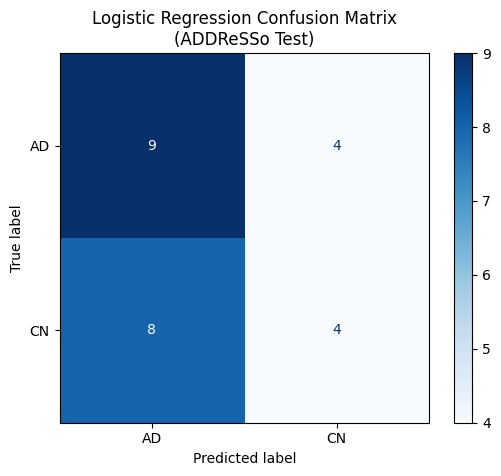


  Evaluating: Logistic Regression | Dataset: WLS External
Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 0.7000
Specificity: 0.7000
F1-Score:    0.5833
ROC-AUC:     0.5375

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.70      0.58        20
          CN       0.50      0.30      0.38        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.48        40
weighted avg       0.50      0.50      0.48        40

------------------------------------------------------------


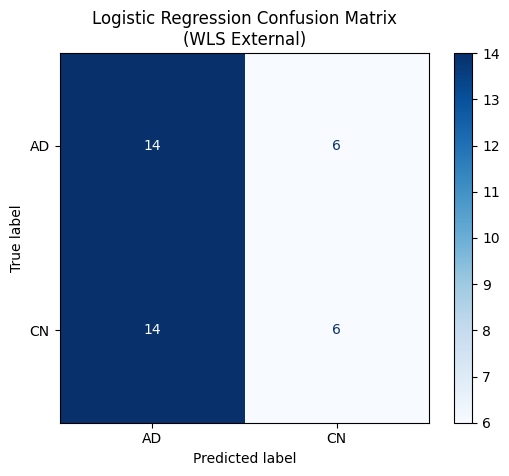


  Evaluating: Random Forest | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.7500
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7200
ROC-AUC:     0.6783

Classification Report:
              precision    recall  f1-score   support

          AD       0.75      0.69      0.72        13
          CN       0.67      0.73      0.70        11

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.71      0.71      0.71        24

------------------------------------------------------------


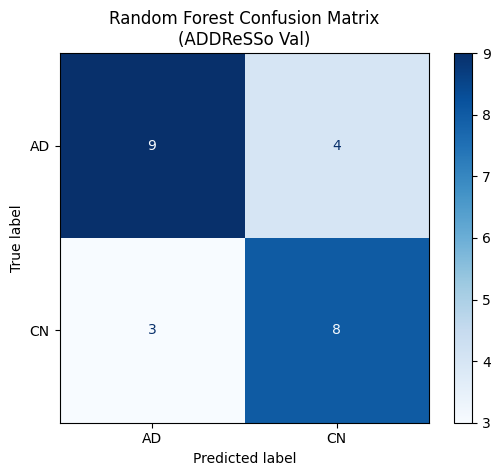


  Evaluating: Random Forest | Dataset: ADDReSSo Test
Accuracy:    0.5600
Precision:   0.5625
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6207
ROC-AUC:     0.4808

Classification Report:
              precision    recall  f1-score   support

          AD       0.56      0.69      0.62        13
          CN       0.56      0.42      0.48        12

    accuracy                           0.56        25
   macro avg       0.56      0.55      0.55        25
weighted avg       0.56      0.56      0.55        25

------------------------------------------------------------


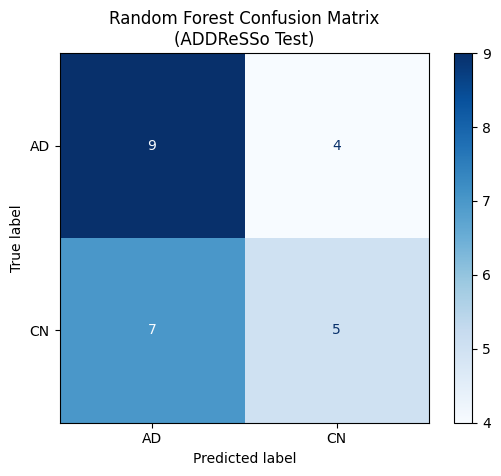


  Evaluating: Random Forest | Dataset: WLS External
Accuracy:    0.4250
Precision:   0.4595
Sensitivity: 0.8500
Specificity: 0.8500
F1-Score:    0.5965
ROC-AUC:     0.5000

Classification Report:
              precision    recall  f1-score   support

          AD       0.46      0.85      0.60        20
          CN       0.00      0.00      0.00        20

    accuracy                           0.42        40
   macro avg       0.23      0.42      0.30        40
weighted avg       0.23      0.42      0.30        40

------------------------------------------------------------


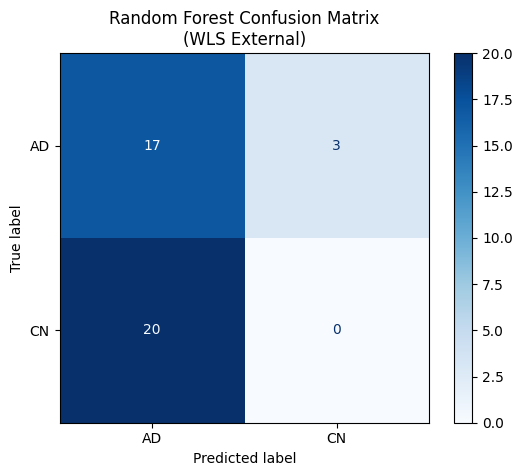


  Evaluating: Gradient Boosting | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.6429
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6667
ROC-AUC:     0.6014

Classification Report:
              precision    recall  f1-score   support

          AD       0.64      0.69      0.67        13
          CN       0.60      0.55      0.57        11

    accuracy                           0.62        24
   macro avg       0.62      0.62      0.62        24
weighted avg       0.62      0.62      0.62        24

------------------------------------------------------------


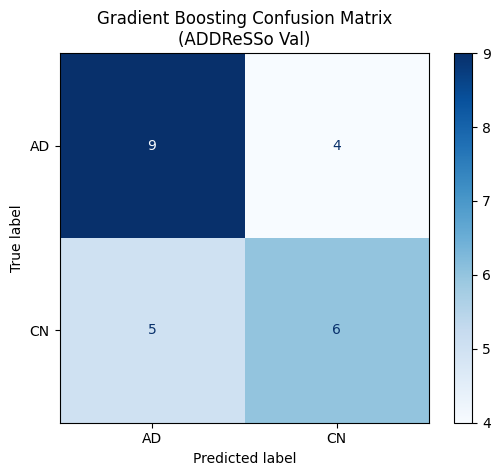


  Evaluating: Gradient Boosting | Dataset: ADDReSSo Test
Accuracy:    0.4800
Precision:   0.5000
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.5185
ROC-AUC:     0.4744

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.54      0.52        13
          CN       0.45      0.42      0.43        12

    accuracy                           0.48        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.48      0.48      0.48        25

------------------------------------------------------------


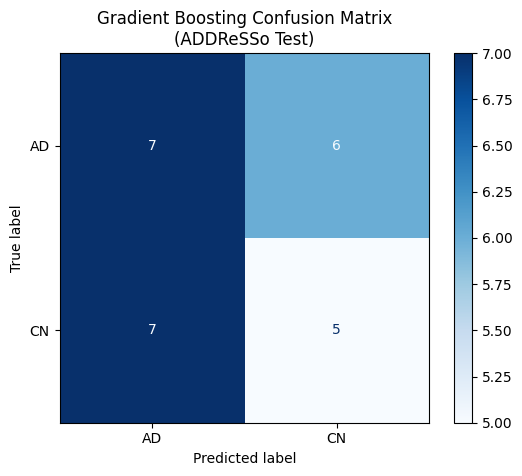


  Evaluating: Gradient Boosting | Dataset: WLS External
Accuracy:    0.5250
Precision:   0.5143
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6545
ROC-AUC:     0.5225

Classification Report:
              precision    recall  f1-score   support

          AD       0.51      0.90      0.65        20
          CN       0.60      0.15      0.24        20

    accuracy                           0.53        40
   macro avg       0.56      0.53      0.45        40
weighted avg       0.56      0.53      0.45        40

------------------------------------------------------------


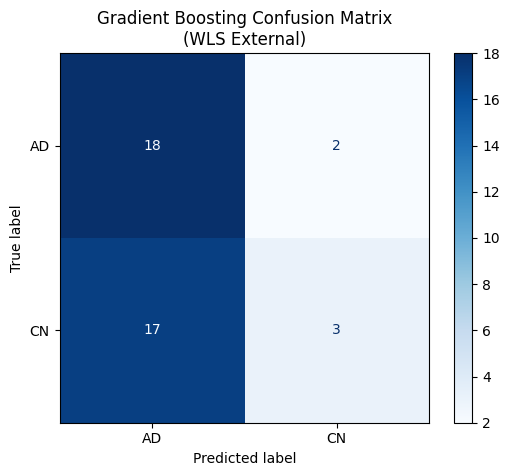


  Evaluating: XGBoost | Dataset: ADDReSSo Val
Accuracy:    0.5833
Precision:   0.6000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6429
ROC-AUC:     0.6573

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.69      0.64        13
          CN       0.56      0.45      0.50        11

    accuracy                           0.58        24
   macro avg       0.58      0.57      0.57        24
weighted avg       0.58      0.58      0.58        24

------------------------------------------------------------


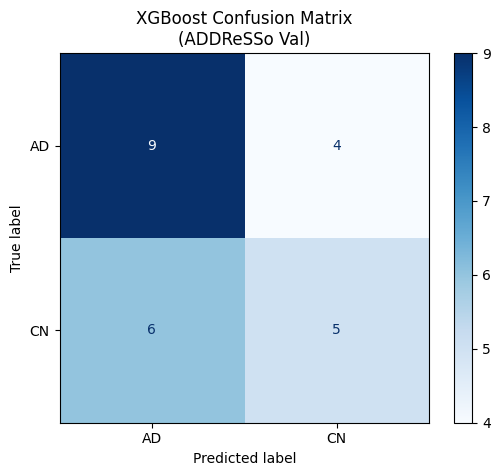


  Evaluating: XGBoost | Dataset: ADDReSSo Test
Accuracy:    0.4800
Precision:   0.5000
Sensitivity: 0.4615
Specificity: 0.4615
F1-Score:    0.4800
ROC-AUC:     0.4872

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.46      0.48        13
          CN       0.46      0.50      0.48        12

    accuracy                           0.48        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.48      0.48      0.48        25

------------------------------------------------------------


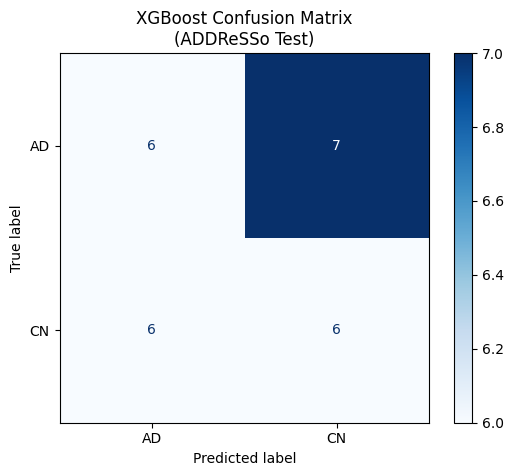


  Evaluating: XGBoost | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.5455
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6792
ROC-AUC:     0.4875

Classification Report:
              precision    recall  f1-score   support

          AD       0.55      0.90      0.68        20
          CN       0.71      0.25      0.37        20

    accuracy                           0.57        40
   macro avg       0.63      0.57      0.52        40
weighted avg       0.63      0.57      0.52        40

------------------------------------------------------------


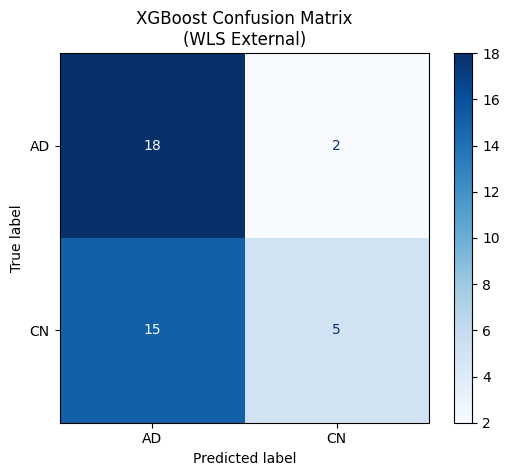


  Evaluating: LightGBM | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.6429
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6667
ROC-AUC:     0.5734

Classification Report:
              precision    recall  f1-score   support

          AD       0.64      0.69      0.67        13
          CN       0.60      0.55      0.57        11

    accuracy                           0.62        24
   macro avg       0.62      0.62      0.62        24
weighted avg       0.62      0.62      0.62        24

------------------------------------------------------------


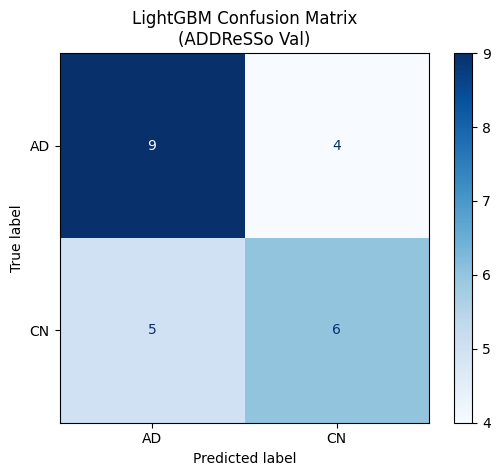


  Evaluating: LightGBM | Dataset: ADDReSSo Test
Accuracy:    0.5200
Precision:   0.5333
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.5714
ROC-AUC:     0.4872

Classification Report:
              precision    recall  f1-score   support

          AD       0.53      0.62      0.57        13
          CN       0.50      0.42      0.45        12

    accuracy                           0.52        25
   macro avg       0.52      0.52      0.51        25
weighted avg       0.52      0.52      0.52        25

------------------------------------------------------------


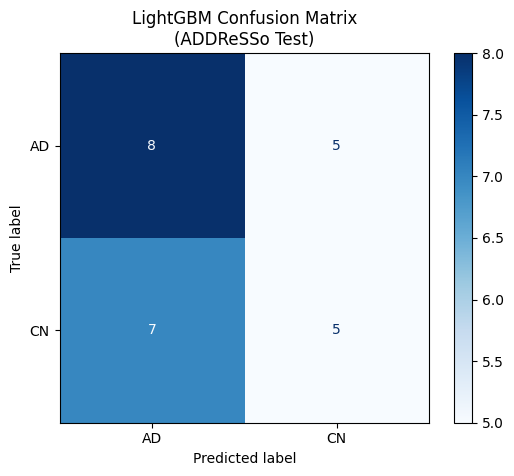


  Evaluating: LightGBM | Dataset: WLS External
Accuracy:    0.5250
Precision:   0.5143
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6545
ROC-AUC:     0.6275

Classification Report:
              precision    recall  f1-score   support

          AD       0.51      0.90      0.65        20
          CN       0.60      0.15      0.24        20

    accuracy                           0.53        40
   macro avg       0.56      0.53      0.45        40
weighted avg       0.56      0.53      0.45        40

------------------------------------------------------------


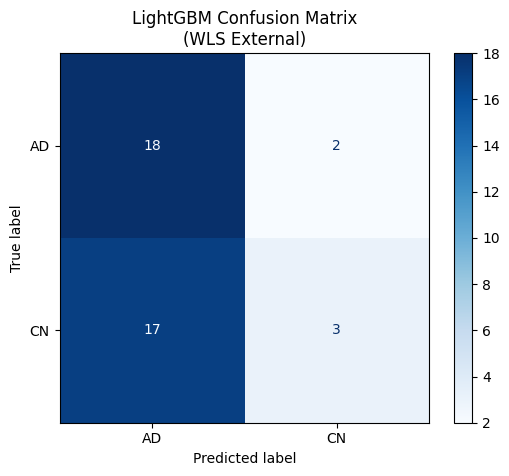


  Evaluating: KNN | Dataset: ADDReSSo Val
Accuracy:    0.5833
Precision:   0.6000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6429
ROC-AUC:     0.6049

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.69      0.64        13
          CN       0.56      0.45      0.50        11

    accuracy                           0.58        24
   macro avg       0.58      0.57      0.57        24
weighted avg       0.58      0.58      0.58        24

------------------------------------------------------------


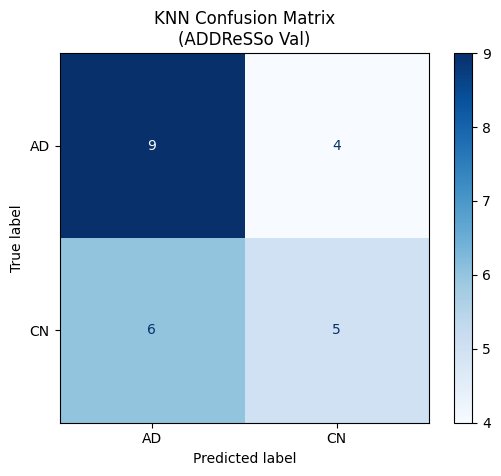


  Evaluating: KNN | Dataset: ADDReSSo Test
Accuracy:    0.5600
Precision:   0.5714
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.5926
ROC-AUC:     0.5897

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.62      0.59        13
          CN       0.55      0.50      0.52        12

    accuracy                           0.56        25
   macro avg       0.56      0.56      0.56        25
weighted avg       0.56      0.56      0.56        25

------------------------------------------------------------


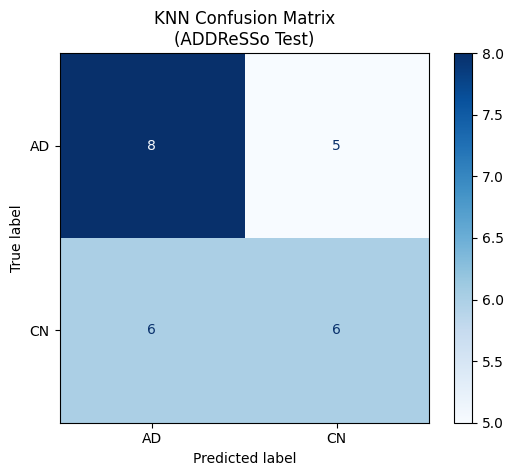


  Evaluating: KNN | Dataset: WLS External
Accuracy:    0.4250
Precision:   0.4545
Sensitivity: 0.7500
Specificity: 0.7500
F1-Score:    0.5660
ROC-AUC:     0.4075

Classification Report:
              precision    recall  f1-score   support

          AD       0.45      0.75      0.57        20
          CN       0.29      0.10      0.15        20

    accuracy                           0.42        40
   macro avg       0.37      0.42      0.36        40
weighted avg       0.37      0.42      0.36        40

------------------------------------------------------------


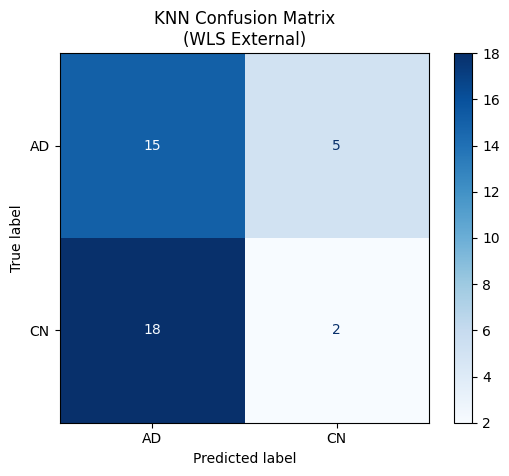


  Evaluating: Neural Network (MLP) | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.8000
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6957
ROC-AUC:     0.7622

Classification Report:
              precision    recall  f1-score   support

          AD       0.80      0.62      0.70        13
          CN       0.64      0.82      0.72        11

    accuracy                           0.71        24
   macro avg       0.72      0.72      0.71        24
weighted avg       0.73      0.71      0.71        24

------------------------------------------------------------


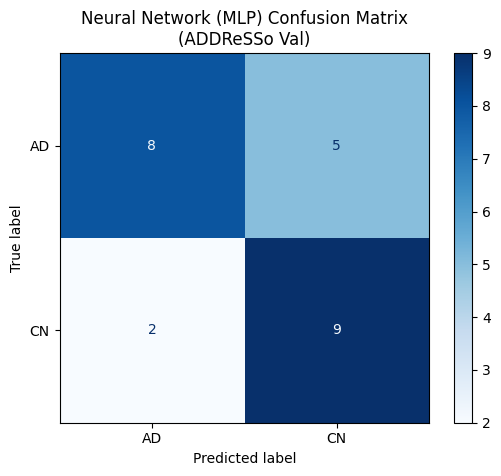


  Evaluating: Neural Network (MLP) | Dataset: ADDReSSo Test
Accuracy:    0.6800
Precision:   0.6471
Sensitivity: 0.8462
Specificity: 0.8462
F1-Score:    0.7333
ROC-AUC:     0.7564

Classification Report:
              precision    recall  f1-score   support

          AD       0.65      0.85      0.73        13
          CN       0.75      0.50      0.60        12

    accuracy                           0.68        25
   macro avg       0.70      0.67      0.67        25
weighted avg       0.70      0.68      0.67        25

------------------------------------------------------------


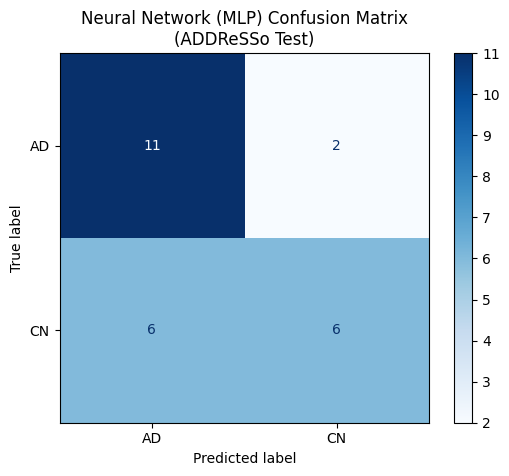


  Evaluating: Neural Network (MLP) | Dataset: WLS External
Accuracy:    0.6000
Precision:   0.6000
Sensitivity: 0.6000
Specificity: 0.6000
F1-Score:    0.6000
ROC-AUC:     0.5950

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.60      0.60        20
          CN       0.60      0.60      0.60        20

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40

------------------------------------------------------------


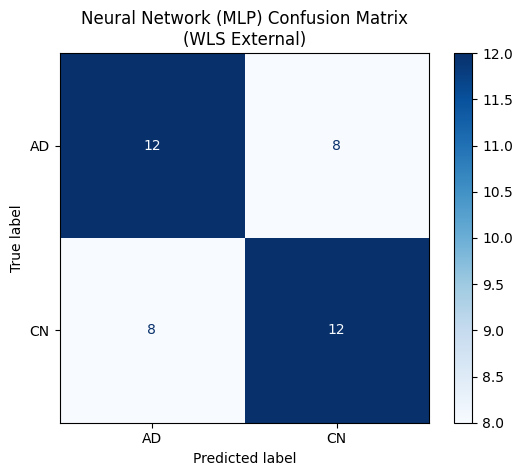

In [21]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Define the suite of models
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1), # verbose=-1 silences warnings
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}

print("--- Training and Evaluating Acoustic Models ---")

# Iterate through the suite of models
for name, model in models.items():
    # 1. Train ONLY on the ENCODED training labels
    model.fit(X_train_audio_scaled, y_train_encoded)

    # Bundle our evaluation sets to loop through them cleanly
    eval_sets = [
        ("ADDReSSo Val", X_val_audio_scaled, y_val),
        ("ADDReSSo Test", X_test_audio_scaled, y_test),
        ("WLS External", X_wls_audio_scaled, y_wls)
    ]

    for dataset_name, X_eval, y_eval in eval_sets:
        # 2. Predict (outputs 0s and 1s)
        y_pred_encoded = model.predict(X_eval)

        # 3. Decode predictions back to 'AD' and 'CN' for the evaluation function
        y_pred = le.inverse_transform(y_pred_encoded)

        # 4. Get probability for ROC-AUC
        #    Because we explicitly mapped AD to 1, the probability of AD is now safely at index 1
        y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

        # 5. Evaluate using our updated function
        metrics = evaluate_clinical_model(name, dataset_name, y_eval, y_pred, y_proba, pos_label='AD')

        # Tag whether this was Acoustic or Linguistic
        metrics['Feature_Type'] = 'Acoustic'

        # Add to our master list
        global_summary_metrics.append(metrics)


## Model Tuning and Re-evaluating

--- Commencing Hyperparameter Tuning for Acoustic Models ---
Note: This will take a few minutes to run cross-validation...

Tuning SVM...
  Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}

  Evaluating: SVM (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.5417
Precision:   0.5625
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6207
ROC-AUC:     0.6993

Classification Report:
              precision    recall  f1-score   support

          AD       0.56      0.69      0.62        13
          CN       0.50      0.36      0.42        11

    accuracy                           0.54        24
   macro avg       0.53      0.53      0.52        24
weighted avg       0.53      0.54      0.53        24

------------------------------------------------------------


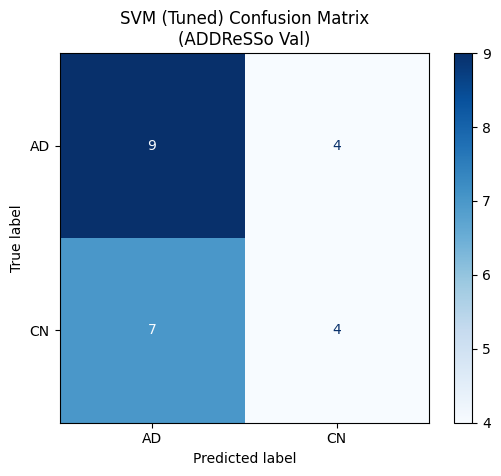


  Evaluating: SVM (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6000
Precision:   0.5714
Sensitivity: 0.9231
Specificity: 0.9231
F1-Score:    0.7059
ROC-AUC:     0.5705

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.92      0.71        13
          CN       0.75      0.25      0.38        12

    accuracy                           0.60        25
   macro avg       0.66      0.59      0.54        25
weighted avg       0.66      0.60      0.55        25

------------------------------------------------------------


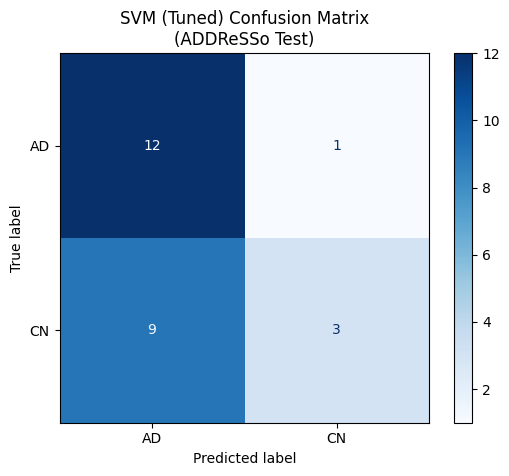


  Evaluating: SVM (Tuned) | Dataset: WLS External
Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 1.0000
Specificity: 1.0000
F1-Score:    0.6667
ROC-AUC:     0.5950

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      1.00      0.67        20
          CN       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40

------------------------------------------------------------


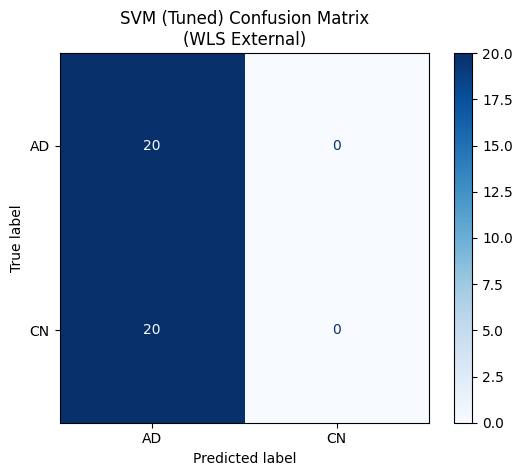

Tuning Logistic Regression...
  Best Params: {'class_weight': None, 'C': 0.1}

  Evaluating: Logistic Regression (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.7000
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6087
ROC-AUC:     0.6713

Classification Report:
              precision    recall  f1-score   support

          AD       0.70      0.54      0.61        13
          CN       0.57      0.73      0.64        11

    accuracy                           0.62        24
   macro avg       0.64      0.63      0.62        24
weighted avg       0.64      0.62      0.62        24

------------------------------------------------------------


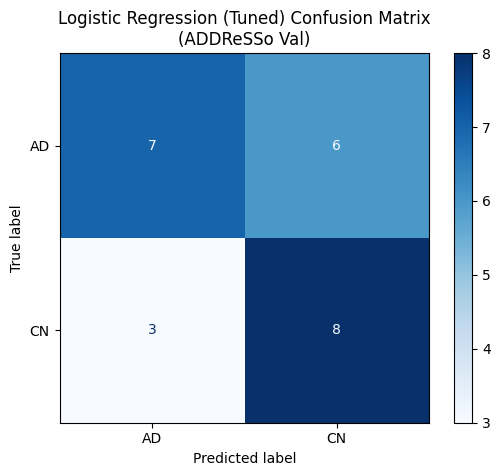


  Evaluating: Logistic Regression (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6000
Precision:   0.5882
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.6667
ROC-AUC:     0.6282

Classification Report:
              precision    recall  f1-score   support

          AD       0.59      0.77      0.67        13
          CN       0.62      0.42      0.50        12

    accuracy                           0.60        25
   macro avg       0.61      0.59      0.58        25
weighted avg       0.61      0.60      0.59        25

------------------------------------------------------------


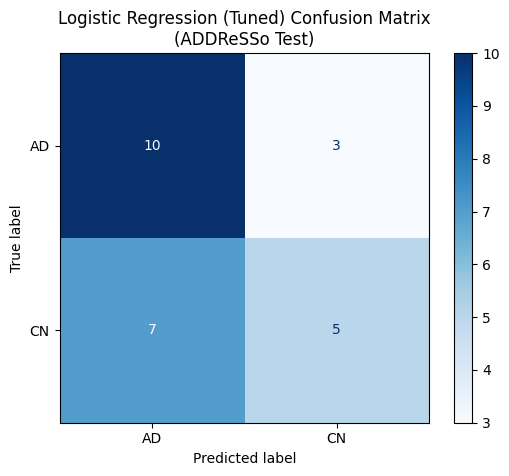


  Evaluating: Logistic Regression (Tuned) | Dataset: WLS External
Accuracy:    0.5500
Precision:   0.5357
Sensitivity: 0.7500
Specificity: 0.7500
F1-Score:    0.6250
ROC-AUC:     0.5250

Classification Report:
              precision    recall  f1-score   support

          AD       0.54      0.75      0.62        20
          CN       0.58      0.35      0.44        20

    accuracy                           0.55        40
   macro avg       0.56      0.55      0.53        40
weighted avg       0.56      0.55      0.53        40

------------------------------------------------------------


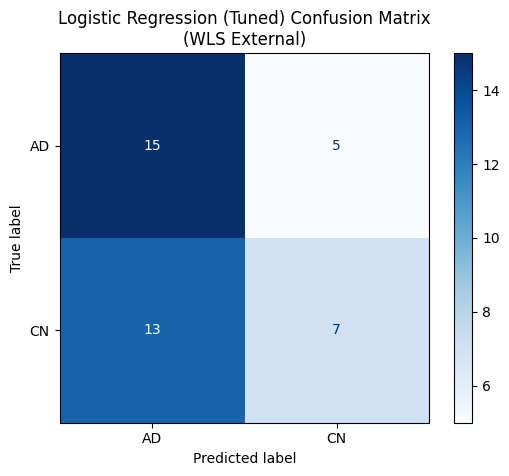

Tuning Random Forest...
  Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}

  Evaluating: Random Forest (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.6923
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6923
ROC-AUC:     0.6643

Classification Report:
              precision    recall  f1-score   support

          AD       0.69      0.69      0.69        13
          CN       0.64      0.64      0.64        11

    accuracy                           0.67        24
   macro avg       0.66      0.66      0.66        24
weighted avg       0.67      0.67      0.67        24

------------------------------------------------------------


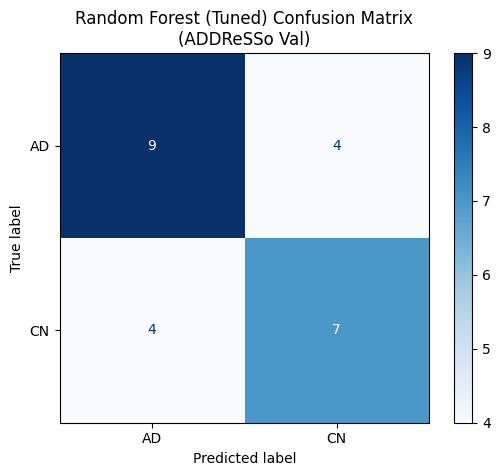


  Evaluating: Random Forest (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.5600
Precision:   0.5556
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.6452
ROC-AUC:     0.4359

Classification Report:
              precision    recall  f1-score   support

          AD       0.56      0.77      0.65        13
          CN       0.57      0.33      0.42        12

    accuracy                           0.56        25
   macro avg       0.56      0.55      0.53        25
weighted avg       0.56      0.56      0.54        25

------------------------------------------------------------


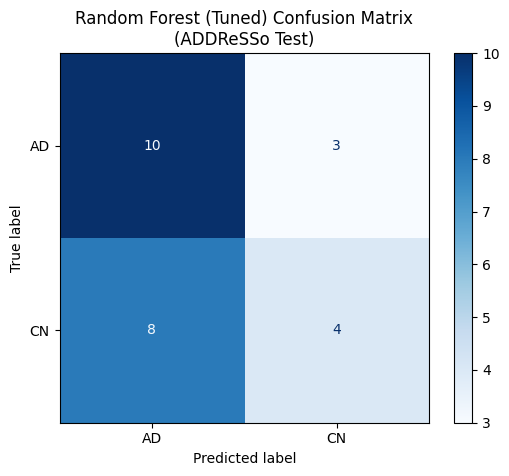


  Evaluating: Random Forest (Tuned) | Dataset: WLS External
Accuracy:    0.4250
Precision:   0.4595
Sensitivity: 0.8500
Specificity: 0.8500
F1-Score:    0.5965
ROC-AUC:     0.4975

Classification Report:
              precision    recall  f1-score   support

          AD       0.46      0.85      0.60        20
          CN       0.00      0.00      0.00        20

    accuracy                           0.42        40
   macro avg       0.23      0.42      0.30        40
weighted avg       0.23      0.42      0.30        40

------------------------------------------------------------


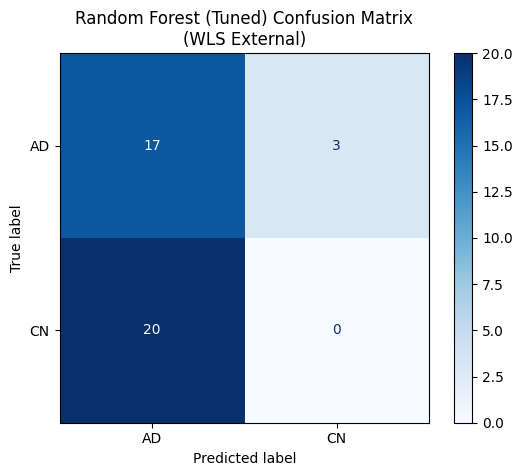

Tuning Gradient Boosting...
  Best Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}

  Evaluating: Gradient Boosting (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.6250
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.6897
ROC-AUC:     0.6573

Classification Report:
              precision    recall  f1-score   support

          AD       0.62      0.77      0.69        13
          CN       0.62      0.45      0.53        11

    accuracy                           0.62        24
   macro avg       0.62      0.61      0.61        24
weighted avg       0.62      0.62      0.61        24

------------------------------------------------------------


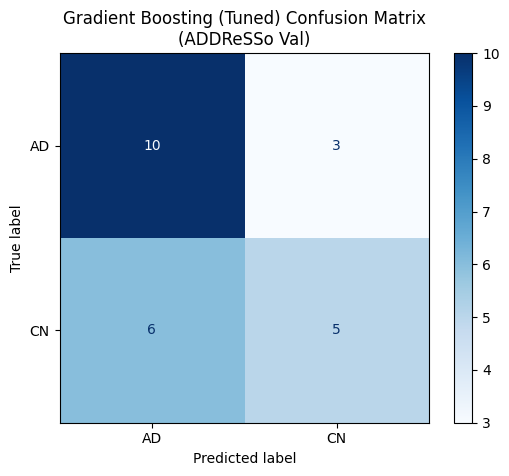


  Evaluating: Gradient Boosting (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.4000
Precision:   0.4000
Sensitivity: 0.3077
Specificity: 0.3077
F1-Score:    0.3478
ROC-AUC:     0.4487

Classification Report:
              precision    recall  f1-score   support

          AD       0.40      0.31      0.35        13
          CN       0.40      0.50      0.44        12

    accuracy                           0.40        25
   macro avg       0.40      0.40      0.40        25
weighted avg       0.40      0.40      0.39        25

------------------------------------------------------------


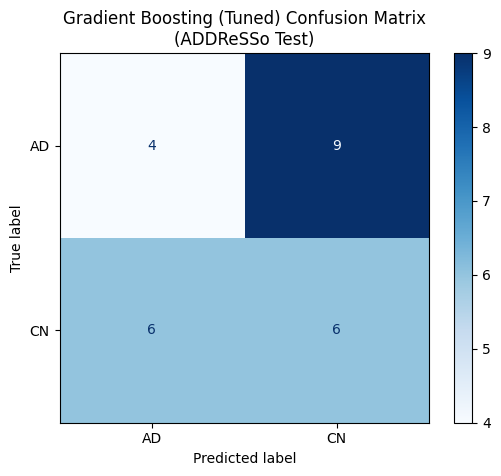


  Evaluating: Gradient Boosting (Tuned) | Dataset: WLS External
Accuracy:    0.5500
Precision:   0.5294
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6667
ROC-AUC:     0.5188

Classification Report:
              precision    recall  f1-score   support

          AD       0.53      0.90      0.67        20
          CN       0.67      0.20      0.31        20

    accuracy                           0.55        40
   macro avg       0.60      0.55      0.49        40
weighted avg       0.60      0.55      0.49        40

------------------------------------------------------------


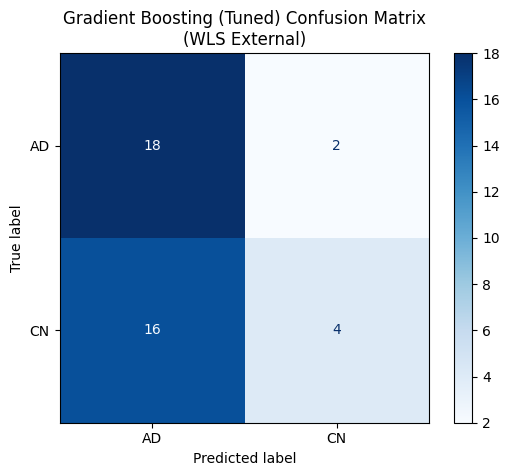

Tuning XGBoost...
  Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}

  Evaluating: XGBoost (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7500
Precision:   0.7692
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.7692
ROC-AUC:     0.6713

Classification Report:
              precision    recall  f1-score   support

          AD       0.77      0.77      0.77        13
          CN       0.73      0.73      0.73        11

    accuracy                           0.75        24
   macro avg       0.75      0.75      0.75        24
weighted avg       0.75      0.75      0.75        24

------------------------------------------------------------


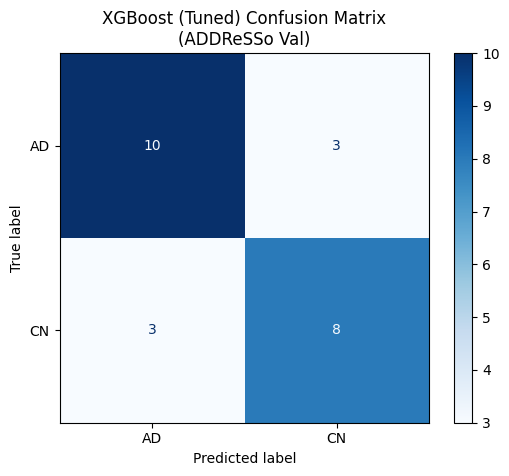


  Evaluating: XGBoost (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.4000
Precision:   0.4167
Sensitivity: 0.3846
Specificity: 0.3846
F1-Score:    0.4000
ROC-AUC:     0.4038

Classification Report:
              precision    recall  f1-score   support

          AD       0.42      0.38      0.40        13
          CN       0.38      0.42      0.40        12

    accuracy                           0.40        25
   macro avg       0.40      0.40      0.40        25
weighted avg       0.40      0.40      0.40        25

------------------------------------------------------------


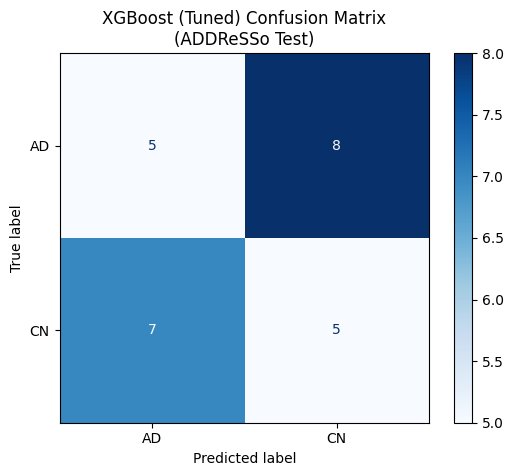


  Evaluating: XGBoost (Tuned) | Dataset: WLS External
Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6429
ROC-AUC:     0.5175

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.90      0.64        20
          CN       0.50      0.10      0.17        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.40        40
weighted avg       0.50      0.50      0.40        40

------------------------------------------------------------


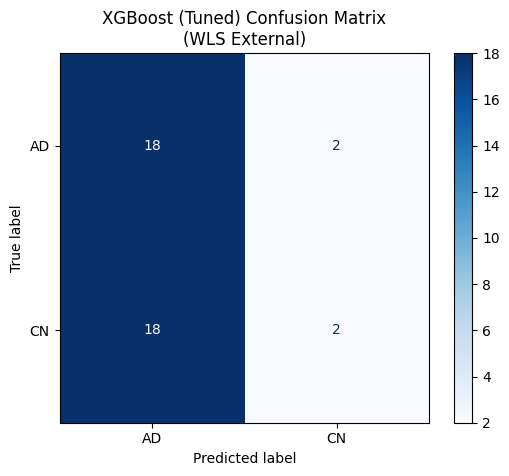

Tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Best Params: {'num_leaves': 15, 'n_estimators': 200, 'learning_rate': 0.2}

  Evaluating: LightGBM (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6250
Precision:   0.6667
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6400
ROC-AUC:     0.6294

Classification Report:
              precision    recall  f1-score   support

          AD       0.67      0.62      0.64        13
          CN       0.58      0.64      0.61        11

    accuracy                           0.62        24
   macro avg       0.62      0.63      0.62        24
weighted avg       0.63      0.62      0.63        24

------------------------------------------------------------


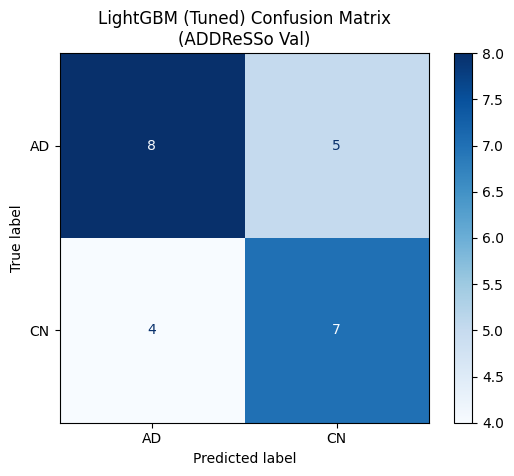


  Evaluating: LightGBM (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.5600
Precision:   0.5714
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.5926
ROC-AUC:     0.4615

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.62      0.59        13
          CN       0.55      0.50      0.52        12

    accuracy                           0.56        25
   macro avg       0.56      0.56      0.56        25
weighted avg       0.56      0.56      0.56        25

------------------------------------------------------------


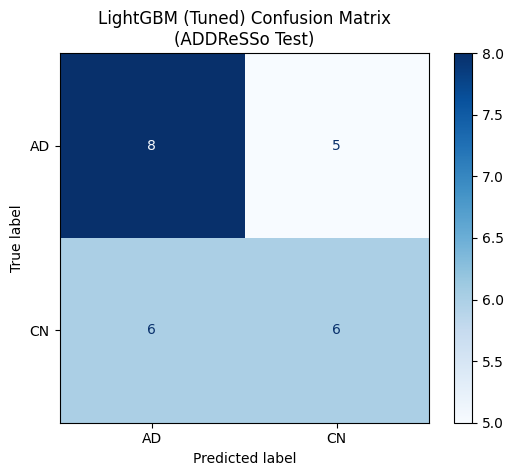


  Evaluating: LightGBM (Tuned) | Dataset: WLS External
Accuracy:    0.5250
Precision:   0.5143
Sensitivity: 0.9000
Specificity: 0.9000
F1-Score:    0.6545
ROC-AUC:     0.5025

Classification Report:
              precision    recall  f1-score   support

          AD       0.51      0.90      0.65        20
          CN       0.60      0.15      0.24        20

    accuracy                           0.53        40
   macro avg       0.56      0.53      0.45        40
weighted avg       0.56      0.53      0.45        40

------------------------------------------------------------


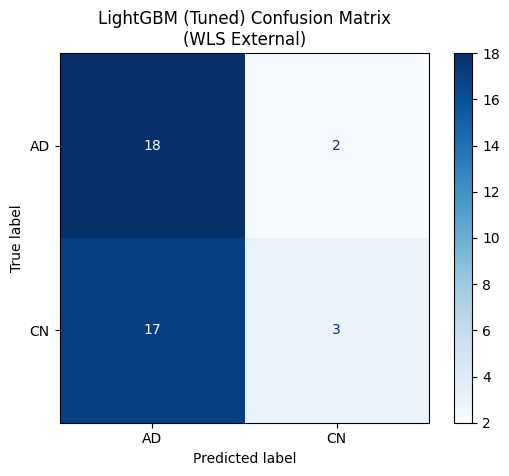

Tuning KNN...
  Best Params: {'weights': 'uniform', 'n_neighbors': 7}

  Evaluating: KNN (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.4583
Precision:   0.5000
Sensitivity: 0.4615
Specificity: 0.4615
F1-Score:    0.4800
ROC-AUC:     0.5979

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.46      0.48        13
          CN       0.42      0.45      0.43        11

    accuracy                           0.46        24
   macro avg       0.46      0.46      0.46        24
weighted avg       0.46      0.46      0.46        24

------------------------------------------------------------


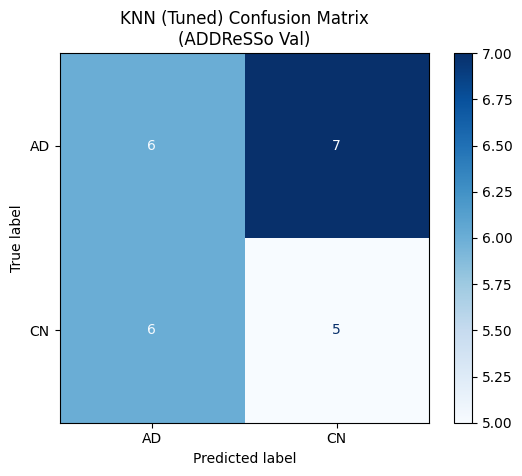


  Evaluating: KNN (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6400
Precision:   0.6111
Sensitivity: 0.8462
Specificity: 0.8462
F1-Score:    0.7097
ROC-AUC:     0.5417

Classification Report:
              precision    recall  f1-score   support

          AD       0.61      0.85      0.71        13
          CN       0.71      0.42      0.53        12

    accuracy                           0.64        25
   macro avg       0.66      0.63      0.62        25
weighted avg       0.66      0.64      0.62        25

------------------------------------------------------------


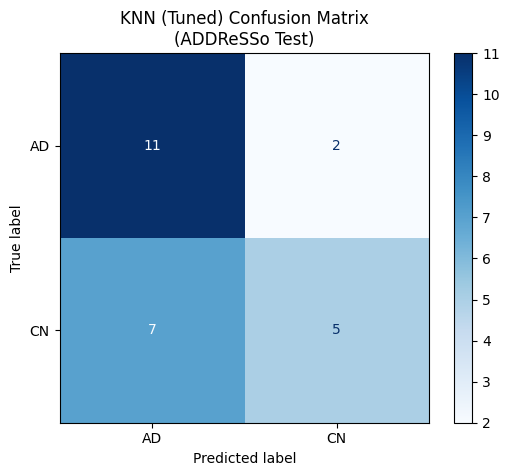


  Evaluating: KNN (Tuned) | Dataset: WLS External
Accuracy:    0.4500
Precision:   0.4706
Sensitivity: 0.8000
Specificity: 0.8000
F1-Score:    0.5926
ROC-AUC:     0.4400

Classification Report:
              precision    recall  f1-score   support

          AD       0.47      0.80      0.59        20
          CN       0.33      0.10      0.15        20

    accuracy                           0.45        40
   macro avg       0.40      0.45      0.37        40
weighted avg       0.40      0.45      0.37        40

------------------------------------------------------------


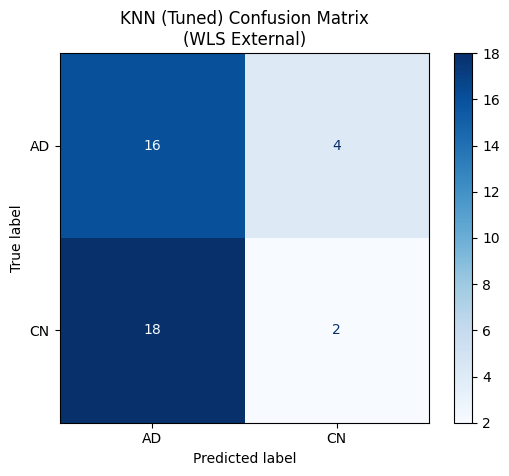

Tuning Neural Network (MLP)...
  Best Params: {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}

  Evaluating: Neural Network (MLP) (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.8000
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6957
ROC-AUC:     0.7622

Classification Report:
              precision    recall  f1-score   support

          AD       0.80      0.62      0.70        13
          CN       0.64      0.82      0.72        11

    accuracy                           0.71        24
   macro avg       0.72      0.72      0.71        24
weighted avg       0.73      0.71      0.71        24

------------------------------------------------------------


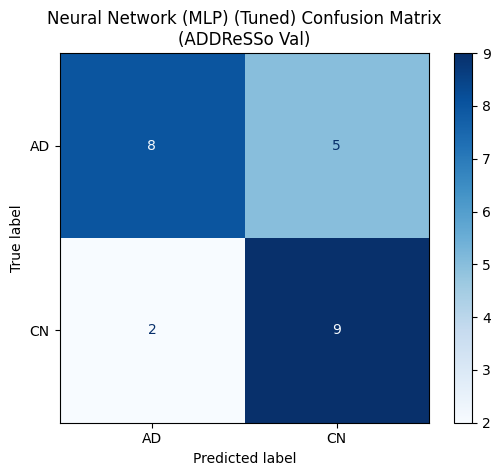


  Evaluating: Neural Network (MLP) (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6800
Precision:   0.6471
Sensitivity: 0.8462
Specificity: 0.8462
F1-Score:    0.7333
ROC-AUC:     0.7564

Classification Report:
              precision    recall  f1-score   support

          AD       0.65      0.85      0.73        13
          CN       0.75      0.50      0.60        12

    accuracy                           0.68        25
   macro avg       0.70      0.67      0.67        25
weighted avg       0.70      0.68      0.67        25

------------------------------------------------------------


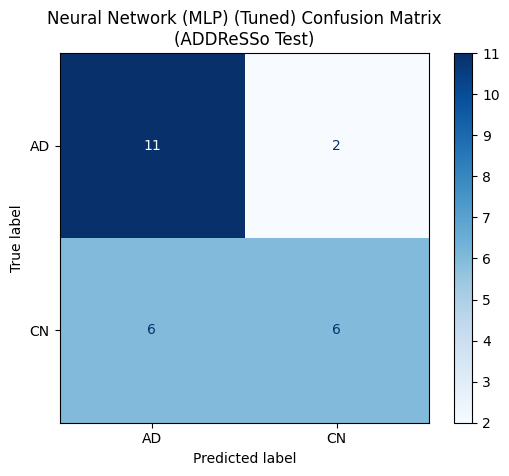


  Evaluating: Neural Network (MLP) (Tuned) | Dataset: WLS External
Accuracy:    0.6000
Precision:   0.6000
Sensitivity: 0.6000
Specificity: 0.6000
F1-Score:    0.6000
ROC-AUC:     0.5950

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.60      0.60        20
          CN       0.60      0.60      0.60        20

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40

------------------------------------------------------------


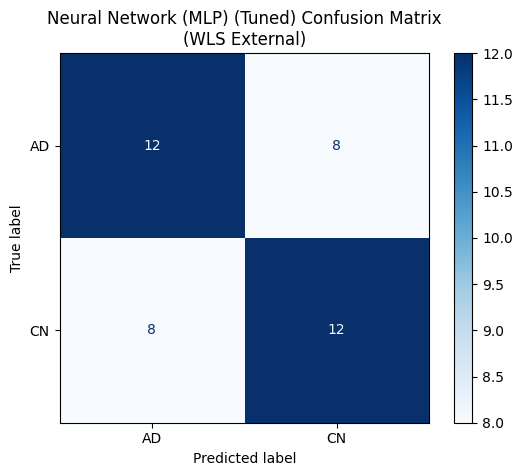

In [22]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# 1. Define the base models (same as before)
models = {
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "KNN": KNeighborsClassifier(),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

# 2. Define the hyperparameter search grids for each model
param_grids = {
    "SVM": {
        'kernel': ['rbf', 'linear'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced']
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 20],      # Limiting depth prevents overfitting
        'min_samples_split': [2, 5, 10]
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]              # Uses a % of data per tree to add randomness
    },
    "LightGBM": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'num_leaves': [15, 31, 50]           # Lower leaves prevent overfitting on small data
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    "Neural Network (MLP)": {
        'hidden_layer_sizes': [(64, 32), (128, 64), (32,)],
        'alpha': [0.0001, 0.001, 0.01]       # L2 penalty to constrain neural weights
    }
}

print("--- Commencing Hyperparameter Tuning for Acoustic Models ---")
print("Note: This will take a few minutes to run cross-validation...\n")

best_models = {}

# Iterate through the suite of models
for name, base_model in models.items():
    print(f"Tuning {name}...")

    # Setup the Randomized Search
    # n_iter=50 means it will test 50 random combinations per model
    # cv=5 means 5-fold cross-validation
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grids[name],
        n_iter=50,
        cv=5,
        scoring='accuracy',
        n_jobs=-1, # Uses all available CPU cores to speed this up
        random_state=42
    )

    # 1. Train and Tune using the ENCODED labels
    search.fit(X_train_audio_scaled, y_train_encoded)

    # Extract the absolute best version of the model
    best_model = search.best_estimator_
    best_models[name] = best_model

    print(f"  Best Params: {search.best_params_}")

    # Bundle our evaluation sets to loop through them cleanly
    eval_sets = [
        ("ADDReSSo Val", X_val_audio_scaled, y_val),
        ("ADDReSSo Test", X_test_audio_scaled, y_test),
        ("WLS External", X_wls_audio_scaled, y_wls)
    ]

    for dataset_name, X_eval, y_eval in eval_sets:
        # 2. Predict (outputs 0s and 1s) using the tuned model
        y_pred_encoded = best_model.predict(X_eval)

        # 3. Decode predictions back to 'AD' and 'CN'
        y_pred = le.inverse_transform(y_pred_encoded)

        # 4. Get probability for ROC-AUC
        # Because we explicitly mapped AD to 1, the probability of AD is now safely at index 1
        y_proba = best_model.predict_proba(X_eval)[:, 1] if hasattr(best_model, "predict_proba") else None

        # 5. Evaluate using the updated function
        metrics = evaluate_clinical_model(f"{name} (Tuned)", dataset_name, y_eval, y_pred, y_proba, pos_label='AD')

        # Tag whether this was Acoustic or Linguistic
        metrics['Feature_Type'] = 'Acoustic'

        # Add to our master list
        global_summary_metrics.append(metrics)

#2. ML Model Training - Linguistic

--- Training and Evaluating Linguistic Models ---

  Evaluating: SVM | Dataset: ADDReSSo Val
Accuracy:    0.7917
Precision:   0.8333
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8000
ROC-AUC:     0.8601

Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.77      0.80        13
          CN       0.75      0.82      0.78        11

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.80      0.79      0.79        24

------------------------------------------------------------


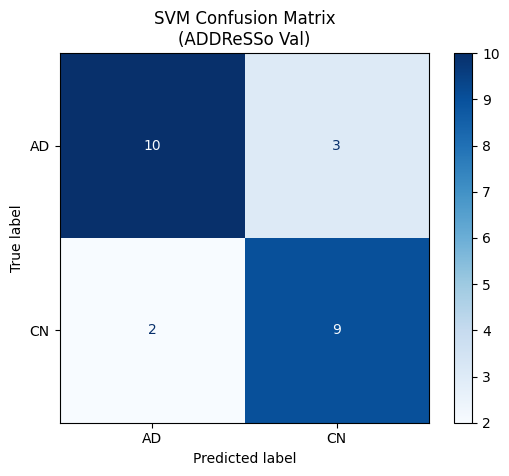


  Evaluating: SVM | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   0.9000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7826
ROC-AUC:     0.8590

Classification Report:
              precision    recall  f1-score   support

          AD       0.90      0.69      0.78        13
          CN       0.73      0.92      0.81        12

    accuracy                           0.80        25
   macro avg       0.82      0.80      0.80        25
weighted avg       0.82      0.80      0.80        25

------------------------------------------------------------


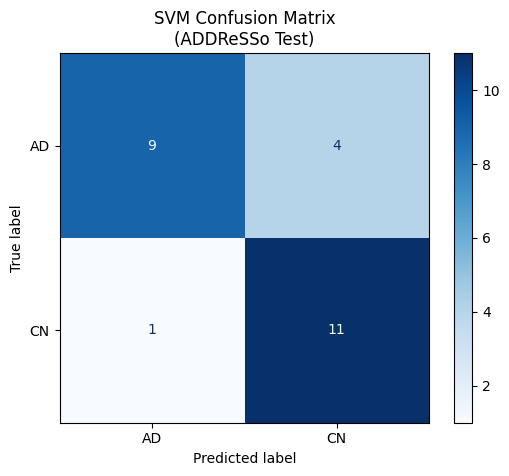


  Evaluating: SVM | Dataset: WLS External
Accuracy:    0.5500
Precision:   0.5500
Sensitivity: 0.5500
Specificity: 0.5500
F1-Score:    0.5500
ROC-AUC:     0.5425

Classification Report:
              precision    recall  f1-score   support

          AD       0.55      0.55      0.55        20
          CN       0.55      0.55      0.55        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40

------------------------------------------------------------


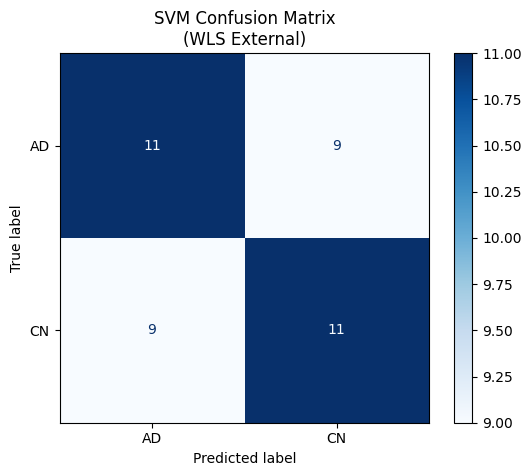


  Evaluating: Logistic Regression | Dataset: ADDReSSo Val
Accuracy:    0.7500
Precision:   0.7692
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.7692
ROC-AUC:     0.8741

Classification Report:
              precision    recall  f1-score   support

          AD       0.77      0.77      0.77        13
          CN       0.73      0.73      0.73        11

    accuracy                           0.75        24
   macro avg       0.75      0.75      0.75        24
weighted avg       0.75      0.75      0.75        24

------------------------------------------------------------


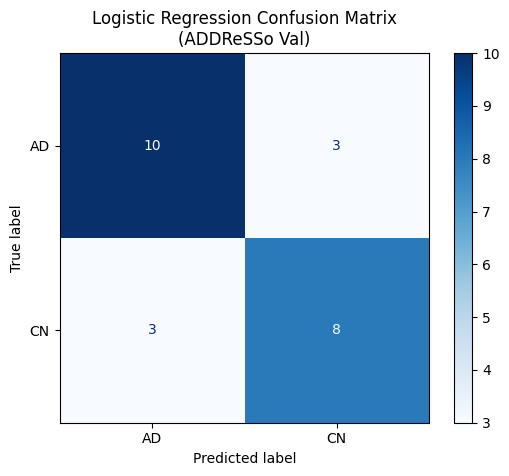


  Evaluating: Logistic Regression | Dataset: ADDReSSo Test
Accuracy:    0.7200
Precision:   0.7500
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7200
ROC-AUC:     0.8397

Classification Report:
              precision    recall  f1-score   support

          AD       0.75      0.69      0.72        13
          CN       0.69      0.75      0.72        12

    accuracy                           0.72        25
   macro avg       0.72      0.72      0.72        25
weighted avg       0.72      0.72      0.72        25

------------------------------------------------------------


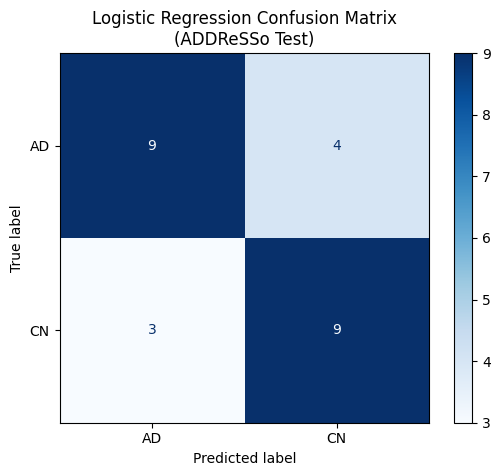


  Evaluating: Logistic Regression | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.5652
Sensitivity: 0.6500
Specificity: 0.6500
F1-Score:    0.6047
ROC-AUC:     0.5550

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.65      0.60        20
          CN       0.59      0.50      0.54        20

    accuracy                           0.57        40
   macro avg       0.58      0.57      0.57        40
weighted avg       0.58      0.57      0.57        40

------------------------------------------------------------


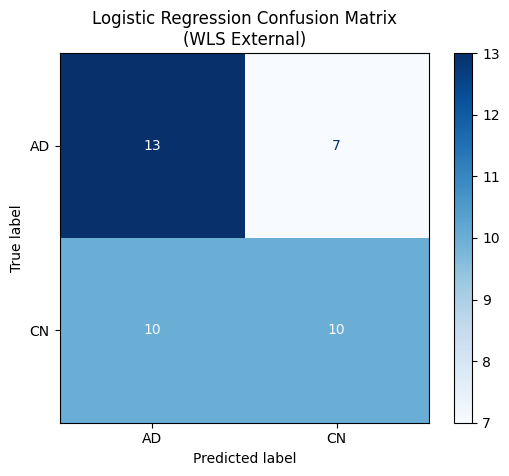


  Evaluating: Random Forest | Dataset: ADDReSSo Val
Accuracy:    0.8333
Precision:   0.9091
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8333
ROC-AUC:     0.8566

Classification Report:
              precision    recall  f1-score   support

          AD       0.91      0.77      0.83        13
          CN       0.77      0.91      0.83        11

    accuracy                           0.83        24
   macro avg       0.84      0.84      0.83        24
weighted avg       0.84      0.83      0.83        24

------------------------------------------------------------


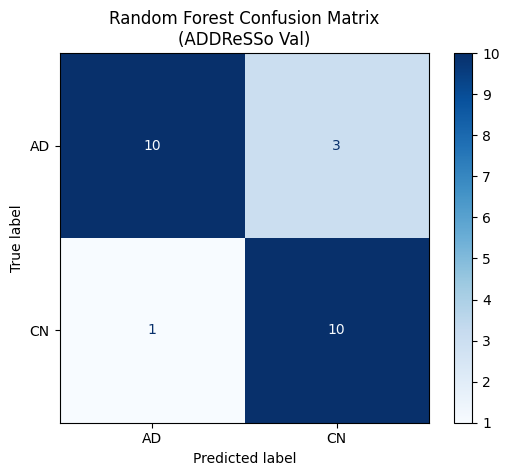


  Evaluating: Random Forest | Dataset: ADDReSSo Test
Accuracy:    0.8400
Precision:   0.9091
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8333
ROC-AUC:     0.8301

Classification Report:
              precision    recall  f1-score   support

          AD       0.91      0.77      0.83        13
          CN       0.79      0.92      0.85        12

    accuracy                           0.84        25
   macro avg       0.85      0.84      0.84        25
weighted avg       0.85      0.84      0.84        25

------------------------------------------------------------


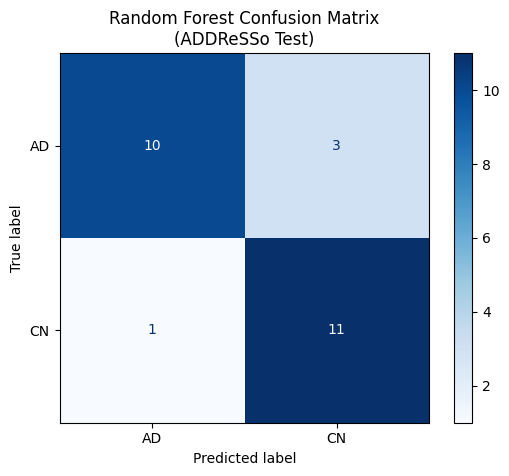


  Evaluating: Random Forest | Dataset: WLS External
Accuracy:    0.6000
Precision:   0.6667
Sensitivity: 0.4000
Specificity: 0.4000
F1-Score:    0.5000
ROC-AUC:     0.5825

Classification Report:
              precision    recall  f1-score   support

          AD       0.67      0.40      0.50        20
          CN       0.57      0.80      0.67        20

    accuracy                           0.60        40
   macro avg       0.62      0.60      0.58        40
weighted avg       0.62      0.60      0.58        40

------------------------------------------------------------


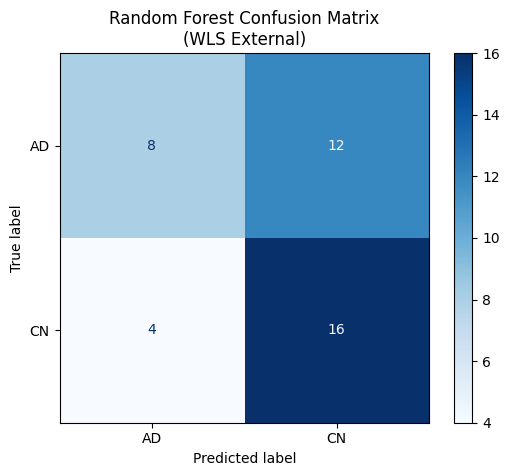


  Evaluating: Gradient Boosting | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.6923
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6923
ROC-AUC:     0.6503

Classification Report:
              precision    recall  f1-score   support

          AD       0.69      0.69      0.69        13
          CN       0.64      0.64      0.64        11

    accuracy                           0.67        24
   macro avg       0.66      0.66      0.66        24
weighted avg       0.67      0.67      0.67        24

------------------------------------------------------------


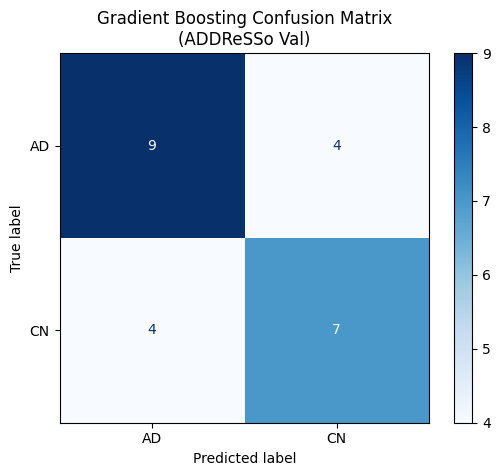


  Evaluating: Gradient Boosting | Dataset: ADDReSSo Test
Accuracy:    0.6400
Precision:   0.7000
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6087
ROC-AUC:     0.6795

Classification Report:
              precision    recall  f1-score   support

          AD       0.70      0.54      0.61        13
          CN       0.60      0.75      0.67        12

    accuracy                           0.64        25
   macro avg       0.65      0.64      0.64        25
weighted avg       0.65      0.64      0.64        25

------------------------------------------------------------


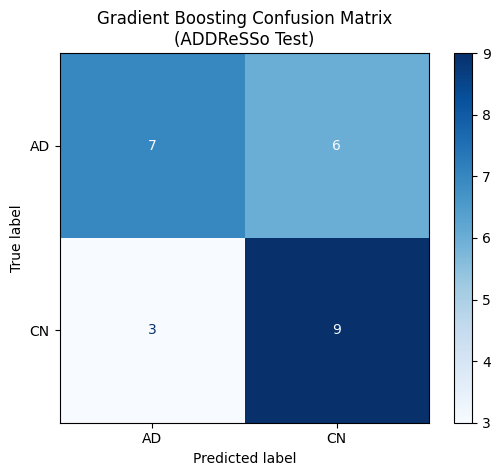


  Evaluating: Gradient Boosting | Dataset: WLS External
Accuracy:    0.4500
Precision:   0.4500
Sensitivity: 0.4500
Specificity: 0.4500
F1-Score:    0.4500
ROC-AUC:     0.5625

Classification Report:
              precision    recall  f1-score   support

          AD       0.45      0.45      0.45        20
          CN       0.45      0.45      0.45        20

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.45        40
weighted avg       0.45      0.45      0.45        40

------------------------------------------------------------


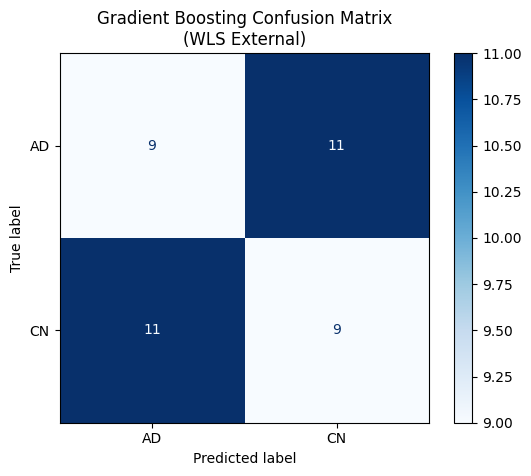


  Evaluating: XGBoost | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.7273
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6667
ROC-AUC:     0.6503

Classification Report:
              precision    recall  f1-score   support

          AD       0.73      0.62      0.67        13
          CN       0.62      0.73      0.67        11

    accuracy                           0.67        24
   macro avg       0.67      0.67      0.67        24
weighted avg       0.68      0.67      0.67        24

------------------------------------------------------------


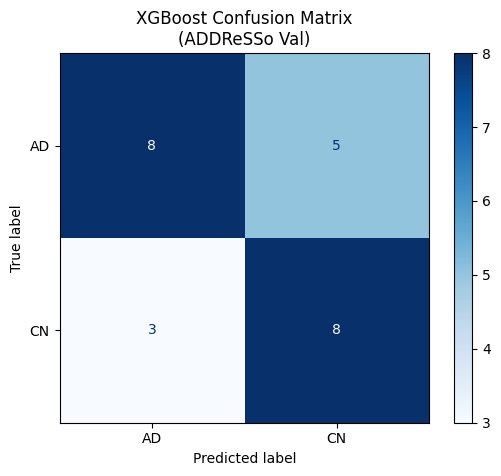


  Evaluating: XGBoost | Dataset: ADDReSSo Test
Accuracy:    0.6400
Precision:   0.6667
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6400
ROC-AUC:     0.7436

Classification Report:
              precision    recall  f1-score   support

          AD       0.67      0.62      0.64        13
          CN       0.62      0.67      0.64        12

    accuracy                           0.64        25
   macro avg       0.64      0.64      0.64        25
weighted avg       0.64      0.64      0.64        25

------------------------------------------------------------


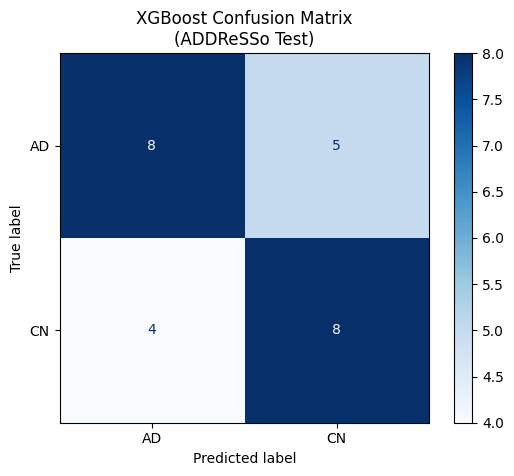


  Evaluating: XGBoost | Dataset: WLS External
Accuracy:    0.5500
Precision:   0.5500
Sensitivity: 0.5500
Specificity: 0.5500
F1-Score:    0.5500
ROC-AUC:     0.5500

Classification Report:
              precision    recall  f1-score   support

          AD       0.55      0.55      0.55        20
          CN       0.55      0.55      0.55        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40

------------------------------------------------------------


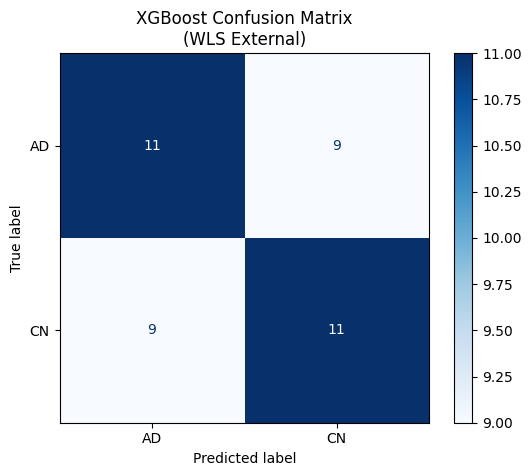


  Evaluating: LightGBM | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.7500
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7200
ROC-AUC:     0.7203

Classification Report:
              precision    recall  f1-score   support

          AD       0.75      0.69      0.72        13
          CN       0.67      0.73      0.70        11

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.71      0.71      0.71        24

------------------------------------------------------------


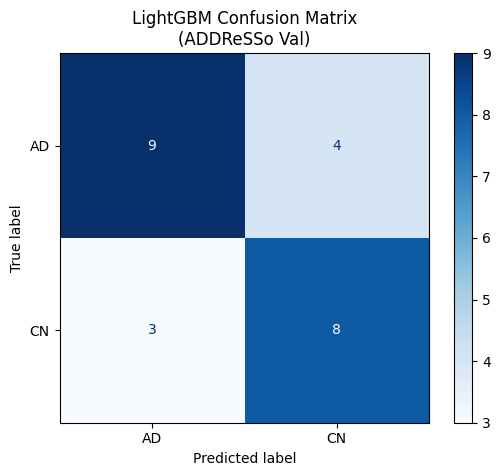


  Evaluating: LightGBM | Dataset: ADDReSSo Test
Accuracy:    0.6400
Precision:   0.6429
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6667
ROC-AUC:     0.7756

Classification Report:
              precision    recall  f1-score   support

          AD       0.64      0.69      0.67        13
          CN       0.64      0.58      0.61        12

    accuracy                           0.64        25
   macro avg       0.64      0.64      0.64        25
weighted avg       0.64      0.64      0.64        25

------------------------------------------------------------


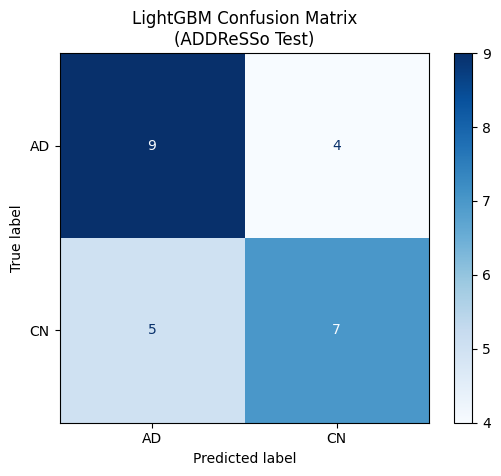


  Evaluating: LightGBM | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.6000
Sensitivity: 0.4500
Specificity: 0.4500
F1-Score:    0.5143
ROC-AUC:     0.4850

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.45      0.51        20
          CN       0.56      0.70      0.62        20

    accuracy                           0.57        40
   macro avg       0.58      0.57      0.57        40
weighted avg       0.58      0.57      0.57        40

------------------------------------------------------------


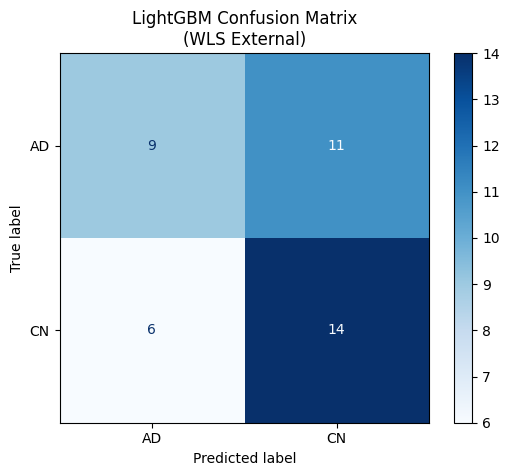


  Evaluating: KNN | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   1.0000
Sensitivity: 0.4615
Specificity: 0.4615
F1-Score:    0.6316
ROC-AUC:     0.8636

Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.46      0.63        13
          CN       0.61      1.00      0.76        11

    accuracy                           0.71        24
   macro avg       0.81      0.73      0.70        24
weighted avg       0.82      0.71      0.69        24

------------------------------------------------------------


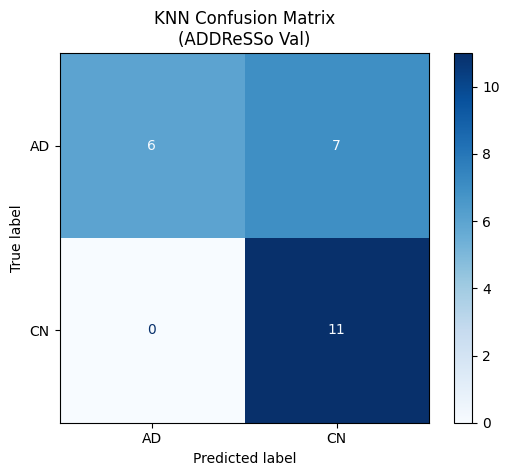


  Evaluating: KNN | Dataset: ADDReSSo Test
Accuracy:    0.7600
Precision:   1.0000
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.7000
ROC-AUC:     0.8558

Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.54      0.70        13
          CN       0.67      1.00      0.80        12

    accuracy                           0.76        25
   macro avg       0.83      0.77      0.75        25
weighted avg       0.84      0.76      0.75        25

------------------------------------------------------------


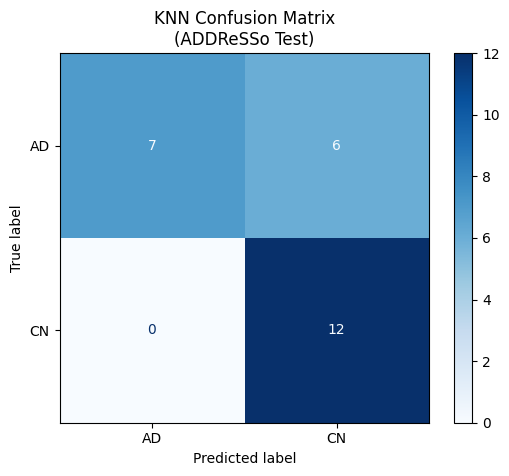


  Evaluating: KNN | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.7143
Sensitivity: 0.2500
Specificity: 0.2500
F1-Score:    0.3704
ROC-AUC:     0.5887

Classification Report:
              precision    recall  f1-score   support

          AD       0.71      0.25      0.37        20
          CN       0.55      0.90      0.68        20

    accuracy                           0.57        40
   macro avg       0.63      0.57      0.52        40
weighted avg       0.63      0.57      0.52        40

------------------------------------------------------------


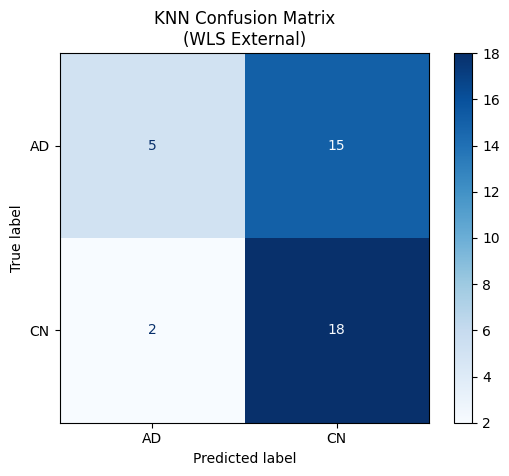


  Evaluating: Neural Network (MLP) | Dataset: ADDReSSo Val
Accuracy:    0.8333
Precision:   0.9091
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8333
ROC-AUC:     0.8671

Classification Report:
              precision    recall  f1-score   support

          AD       0.91      0.77      0.83        13
          CN       0.77      0.91      0.83        11

    accuracy                           0.83        24
   macro avg       0.84      0.84      0.83        24
weighted avg       0.84      0.83      0.83        24

------------------------------------------------------------


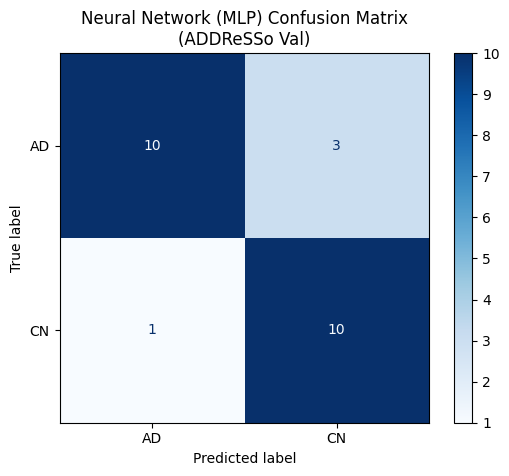


  Evaluating: Neural Network (MLP) | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   0.9000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7826
ROC-AUC:     0.8718

Classification Report:
              precision    recall  f1-score   support

          AD       0.90      0.69      0.78        13
          CN       0.73      0.92      0.81        12

    accuracy                           0.80        25
   macro avg       0.82      0.80      0.80        25
weighted avg       0.82      0.80      0.80        25

------------------------------------------------------------


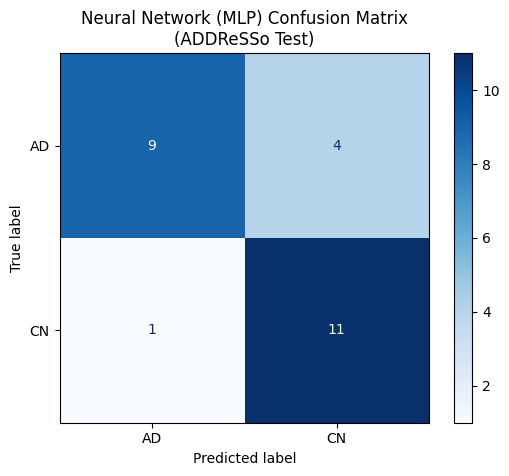


  Evaluating: Neural Network (MLP) | Dataset: WLS External
Accuracy:    0.5500
Precision:   0.5833
Sensitivity: 0.3500
Specificity: 0.3500
F1-Score:    0.4375
ROC-AUC:     0.5500

Classification Report:
              precision    recall  f1-score   support

          AD       0.58      0.35      0.44        20
          CN       0.54      0.75      0.62        20

    accuracy                           0.55        40
   macro avg       0.56      0.55      0.53        40
weighted avg       0.56      0.55      0.53        40

------------------------------------------------------------


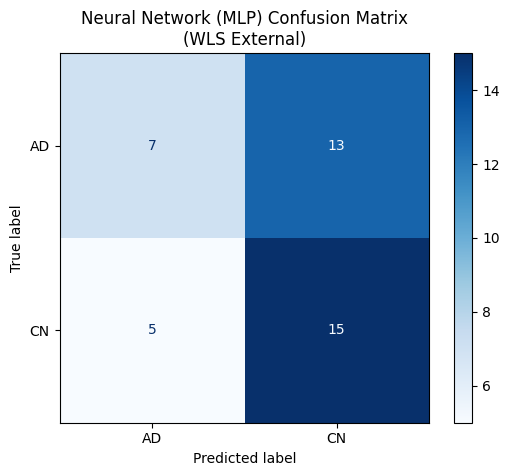

In [23]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Define the suite of models
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1), # verbose=-1 silences warnings
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
}

print("--- Training and Evaluating Linguistic Models ---")

# Iterate through the suite of models
for name, model in models.items():
    # 1. Train on linguistic features and encoded labels
    model.fit(X_train_text, y_train_encoded)

    # Bundle our evaluation sets to loop through them cleanly
    eval_sets = [
        ("ADDReSSo Val", X_val_text, y_val),
        ("ADDReSSo Test", X_test_text, y_test),
        ("WLS External", X_wls_text, y_wls)
    ]

    for dataset_name, X_eval, y_eval in eval_sets:
        # 2. Predict (outputs 0s and 1s)
        y_pred_encoded = model.predict(X_eval)

        # Decode predictions back to 'AD' and 'CN' for a readable report
        y_pred = le.inverse_transform(y_pred_encoded)

        # 3. Get probability for ROC-AUC
        # Because we explicitly mapped AD to 1, the probability of AD is now safely at index 1
        y_proba = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

        # 4. Evaluate using the updated helper function
        metrics = evaluate_clinical_model(name, dataset_name, y_eval, y_pred, y_proba, pos_label='AD')

        # Tag whether this was Acoustic or Linguistic
        metrics['Feature_Type'] = 'Linguistic'

        # Add to our master list
        global_summary_metrics.append(metrics)

## Model Tuning and Re-evaluating

--- Commencing Hyperparameter Tuning for Linguistic Models ---
Note: Running cross-validation. This will take a few minutes...

Tuning SVM...
  Best Params: {'kernel': 'linear', 'gamma': 'scale', 'C': 100}

  Evaluating: SVM (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.8333
Precision:   0.9091
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8333
ROC-AUC:     0.8671

Classification Report:
              precision    recall  f1-score   support

          AD       0.91      0.77      0.83        13
          CN       0.77      0.91      0.83        11

    accuracy                           0.83        24
   macro avg       0.84      0.84      0.83        24
weighted avg       0.84      0.83      0.83        24

------------------------------------------------------------


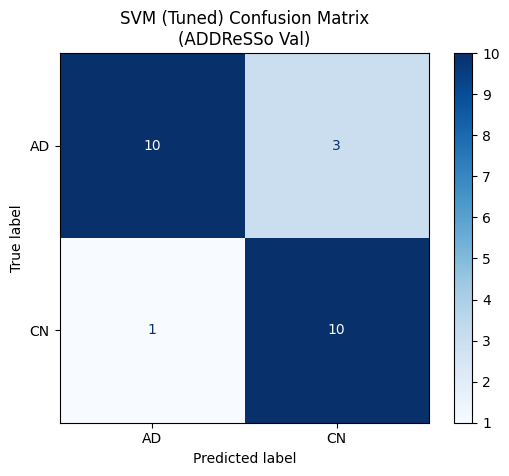


  Evaluating: SVM (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   0.8333
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8000
ROC-AUC:     0.8910

Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.77      0.80        13
          CN       0.77      0.83      0.80        12

    accuracy                           0.80        25
   macro avg       0.80      0.80      0.80        25
weighted avg       0.80      0.80      0.80        25

------------------------------------------------------------


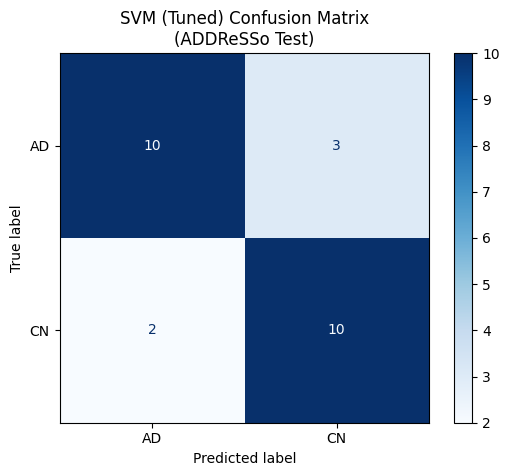


  Evaluating: SVM (Tuned) | Dataset: WLS External
Accuracy:    0.5250
Precision:   0.5333
Sensitivity: 0.4000
Specificity: 0.4000
F1-Score:    0.4571
ROC-AUC:     0.5750

Classification Report:
              precision    recall  f1-score   support

          AD       0.53      0.40      0.46        20
          CN       0.52      0.65      0.58        20

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.53      0.53      0.52        40

------------------------------------------------------------


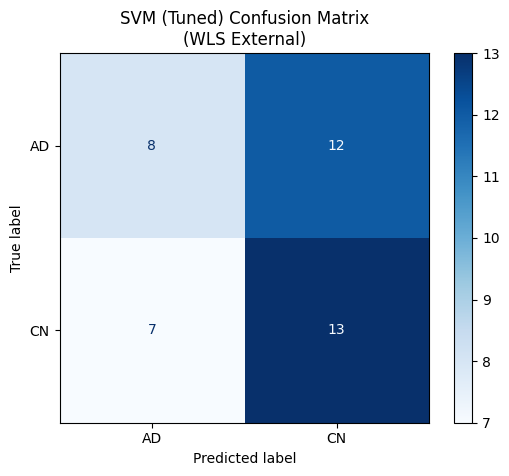

Tuning Logistic Regression...
  Best Params: {'solver': 'liblinear', 'class_weight': 'balanced', 'C': 1}

  Evaluating: Logistic Regression (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7917
Precision:   0.8333
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8000
ROC-AUC:     0.8811

Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.77      0.80        13
          CN       0.75      0.82      0.78        11

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.80      0.79      0.79        24

------------------------------------------------------------


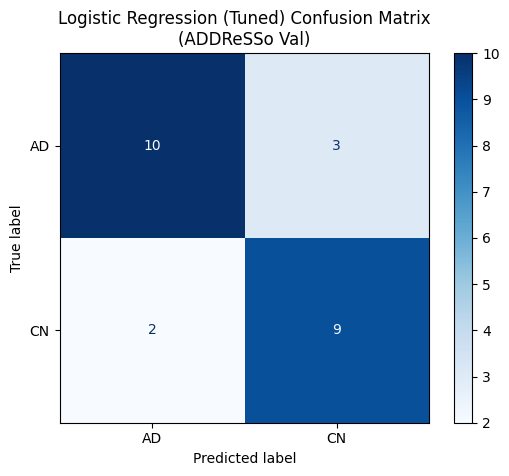


  Evaluating: Logistic Regression (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   1.0000
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.7619
ROC-AUC:     0.8333

Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.62      0.76        13
          CN       0.71      1.00      0.83        12

    accuracy                           0.80        25
   macro avg       0.85      0.81      0.79        25
weighted avg       0.86      0.80      0.79        25

------------------------------------------------------------


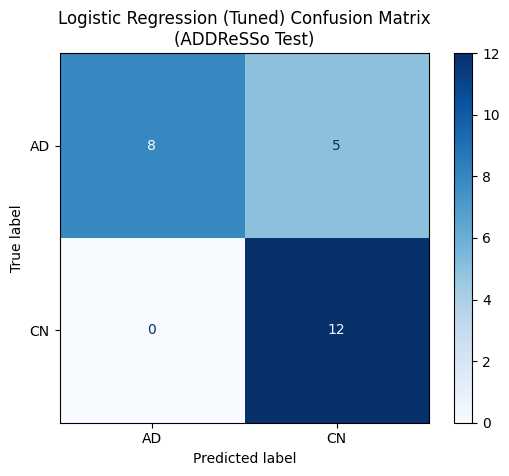


  Evaluating: Logistic Regression (Tuned) | Dataset: WLS External
Accuracy:    0.4500
Precision:   0.4286
Sensitivity: 0.3000
Specificity: 0.3000
F1-Score:    0.3529
ROC-AUC:     0.5600

Classification Report:
              precision    recall  f1-score   support

          AD       0.43      0.30      0.35        20
          CN       0.46      0.60      0.52        20

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.44        40
weighted avg       0.45      0.45      0.44        40

------------------------------------------------------------


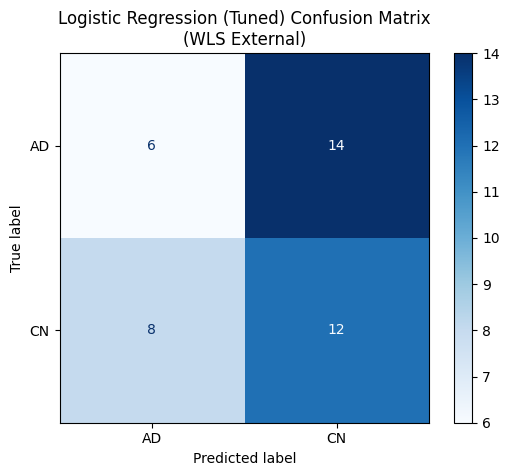

Tuning Random Forest...
  Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 10}

  Evaluating: Random Forest (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7917
Precision:   0.8333
Sensitivity: 0.7692
Specificity: 0.7692
F1-Score:    0.8000
ROC-AUC:     0.8462

Classification Report:
              precision    recall  f1-score   support

          AD       0.83      0.77      0.80        13
          CN       0.75      0.82      0.78        11

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.80      0.79      0.79        24

------------------------------------------------------------


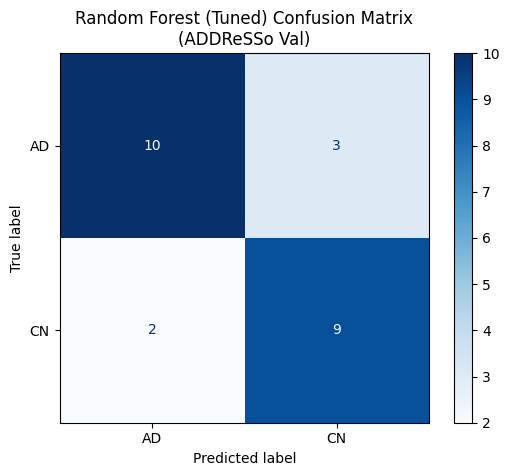


  Evaluating: Random Forest (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   0.9000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7826
ROC-AUC:     0.8333

Classification Report:
              precision    recall  f1-score   support

          AD       0.90      0.69      0.78        13
          CN       0.73      0.92      0.81        12

    accuracy                           0.80        25
   macro avg       0.82      0.80      0.80        25
weighted avg       0.82      0.80      0.80        25

------------------------------------------------------------


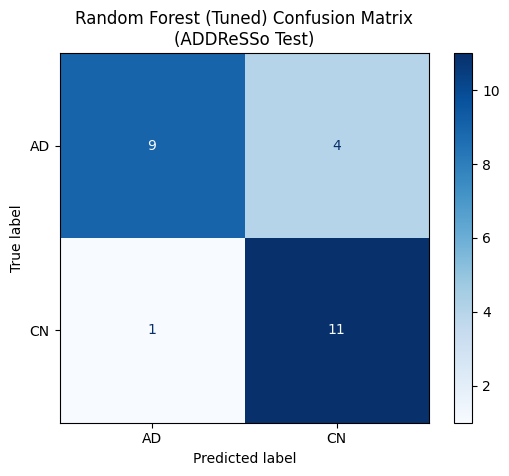


  Evaluating: Random Forest (Tuned) | Dataset: WLS External
Accuracy:    0.6250
Precision:   0.6923
Sensitivity: 0.4500
Specificity: 0.4500
F1-Score:    0.5455
ROC-AUC:     0.5600

Classification Report:
              precision    recall  f1-score   support

          AD       0.69      0.45      0.55        20
          CN       0.59      0.80      0.68        20

    accuracy                           0.62        40
   macro avg       0.64      0.62      0.61        40
weighted avg       0.64      0.62      0.61        40

------------------------------------------------------------


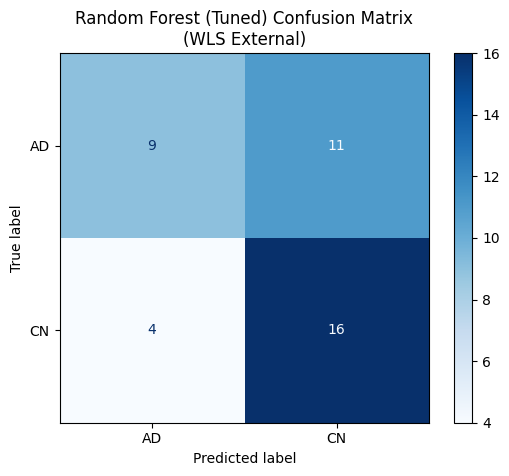

Tuning Gradient Boosting...
  Best Params: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05}

  Evaluating: Gradient Boosting (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.6923
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6923
ROC-AUC:     0.6224

Classification Report:
              precision    recall  f1-score   support

          AD       0.69      0.69      0.69        13
          CN       0.64      0.64      0.64        11

    accuracy                           0.67        24
   macro avg       0.66      0.66      0.66        24
weighted avg       0.67      0.67      0.67        24

------------------------------------------------------------


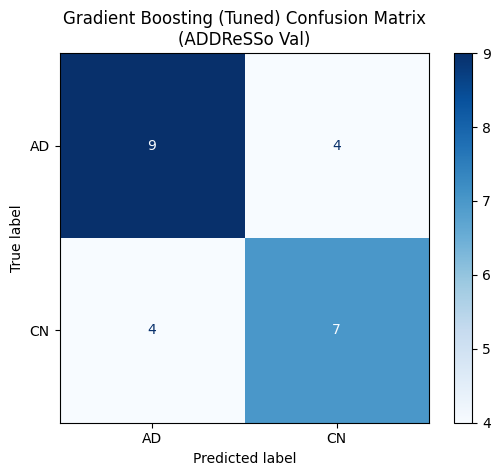


  Evaluating: Gradient Boosting (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6000
Precision:   0.6667
Sensitivity: 0.4615
Specificity: 0.4615
F1-Score:    0.5455
ROC-AUC:     0.6859

Classification Report:
              precision    recall  f1-score   support

          AD       0.67      0.46      0.55        13
          CN       0.56      0.75      0.64        12

    accuracy                           0.60        25
   macro avg       0.61      0.61      0.59        25
weighted avg       0.62      0.60      0.59        25

------------------------------------------------------------


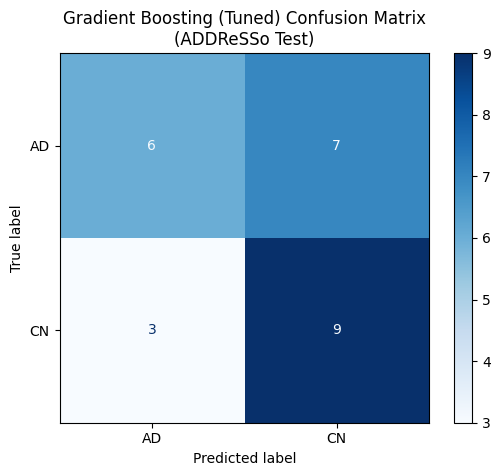


  Evaluating: Gradient Boosting (Tuned) | Dataset: WLS External
Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 0.6000
Specificity: 0.6000
F1-Score:    0.5455
ROC-AUC:     0.5800

Classification Report:
              precision    recall  f1-score   support

          AD       0.50      0.60      0.55        20
          CN       0.50      0.40      0.44        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.49        40
weighted avg       0.50      0.50      0.49        40

------------------------------------------------------------


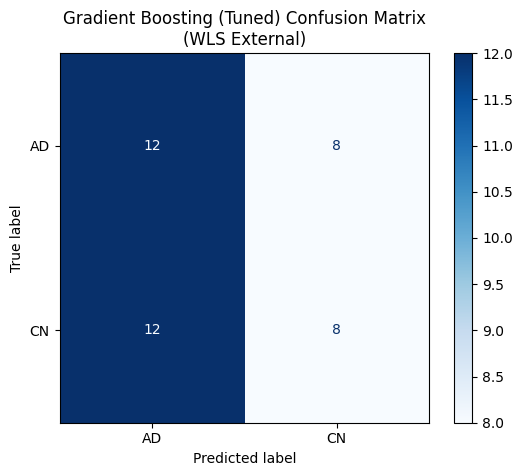

Tuning XGBoost...
  Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

  Evaluating: XGBoost (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.7778
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6364
ROC-AUC:     0.6643

Classification Report:
              precision    recall  f1-score   support

          AD       0.78      0.54      0.64        13
          CN       0.60      0.82      0.69        11

    accuracy                           0.67        24
   macro avg       0.69      0.68      0.66        24
weighted avg       0.70      0.67      0.66        24

------------------------------------------------------------


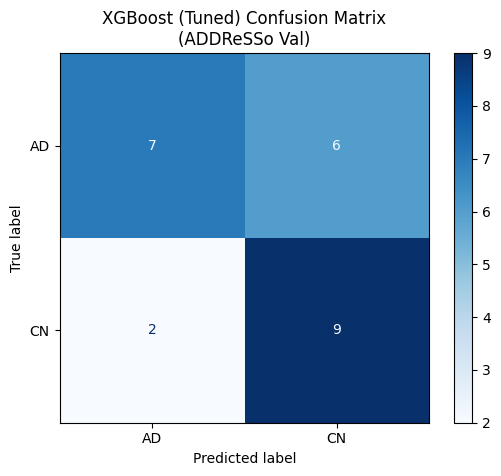


  Evaluating: XGBoost (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6800
Precision:   0.7273
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6667
ROC-AUC:     0.7372

Classification Report:
              precision    recall  f1-score   support

          AD       0.73      0.62      0.67        13
          CN       0.64      0.75      0.69        12

    accuracy                           0.68        25
   macro avg       0.69      0.68      0.68        25
weighted avg       0.69      0.68      0.68        25

------------------------------------------------------------


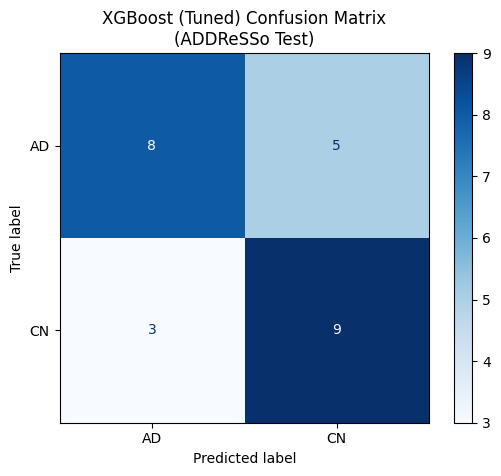


  Evaluating: XGBoost (Tuned) | Dataset: WLS External
Accuracy:    0.6250
Precision:   0.6471
Sensitivity: 0.5500
Specificity: 0.5500
F1-Score:    0.5946
ROC-AUC:     0.5750

Classification Report:
              precision    recall  f1-score   support

          AD       0.65      0.55      0.59        20
          CN       0.61      0.70      0.65        20

    accuracy                           0.62        40
   macro avg       0.63      0.62      0.62        40
weighted avg       0.63      0.62      0.62        40

------------------------------------------------------------


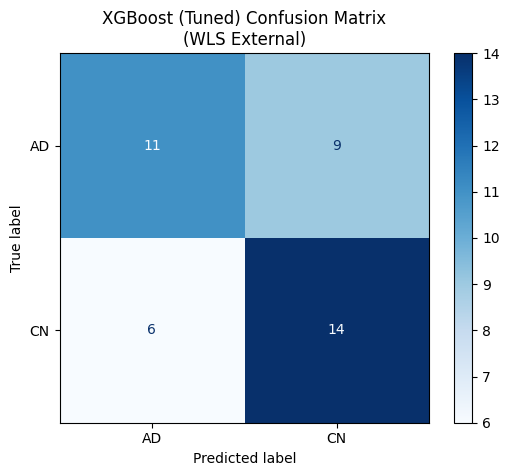

Tuning LightGBM...
  Best Params: {'num_leaves': 15, 'n_estimators': 100, 'learning_rate': 0.1}

  Evaluating: LightGBM (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.7500
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7200
ROC-AUC:     0.7203

Classification Report:
              precision    recall  f1-score   support

          AD       0.75      0.69      0.72        13
          CN       0.67      0.73      0.70        11

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.71      0.71      0.71        24

------------------------------------------------------------


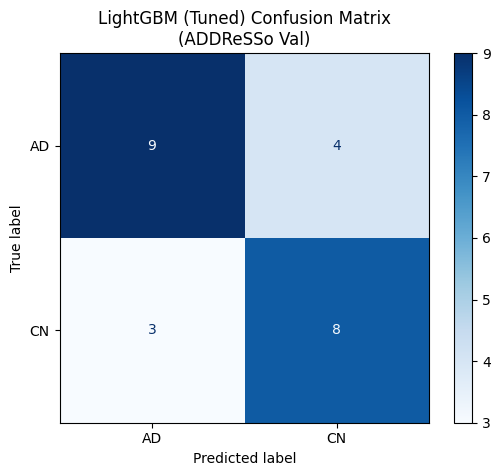


  Evaluating: LightGBM (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.6400
Precision:   0.6429
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.6667
ROC-AUC:     0.7756

Classification Report:
              precision    recall  f1-score   support

          AD       0.64      0.69      0.67        13
          CN       0.64      0.58      0.61        12

    accuracy                           0.64        25
   macro avg       0.64      0.64      0.64        25
weighted avg       0.64      0.64      0.64        25

------------------------------------------------------------


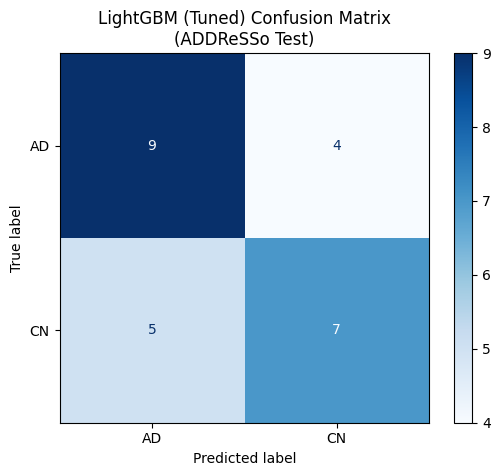


  Evaluating: LightGBM (Tuned) | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.6000
Sensitivity: 0.4500
Specificity: 0.4500
F1-Score:    0.5143
ROC-AUC:     0.4850

Classification Report:
              precision    recall  f1-score   support

          AD       0.60      0.45      0.51        20
          CN       0.56      0.70      0.62        20

    accuracy                           0.57        40
   macro avg       0.58      0.57      0.57        40
weighted avg       0.58      0.57      0.57        40

------------------------------------------------------------


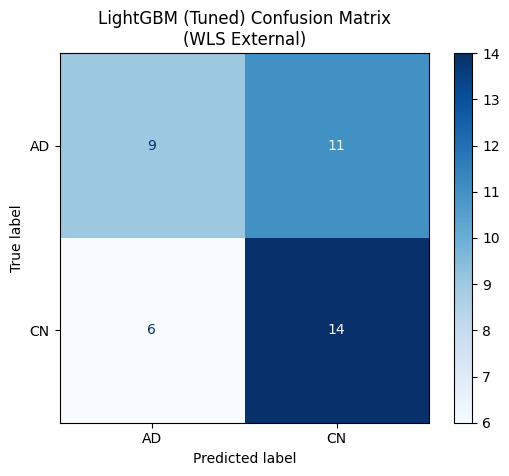

Tuning KNN...
  Best Params: {'weights': 'uniform', 'n_neighbors': 3}

  Evaluating: KNN (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.6667
Precision:   0.7778
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6364
ROC-AUC:     0.8007

Classification Report:
              precision    recall  f1-score   support

          AD       0.78      0.54      0.64        13
          CN       0.60      0.82      0.69        11

    accuracy                           0.67        24
   macro avg       0.69      0.68      0.66        24
weighted avg       0.70      0.67      0.66        24

------------------------------------------------------------


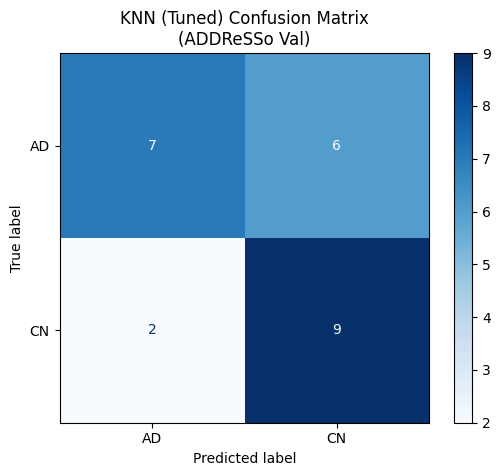


  Evaluating: KNN (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.7200
Precision:   0.8750
Sensitivity: 0.5385
Specificity: 0.5385
F1-Score:    0.6667
ROC-AUC:     0.8173

Classification Report:
              precision    recall  f1-score   support

          AD       0.88      0.54      0.67        13
          CN       0.65      0.92      0.76        12

    accuracy                           0.72        25
   macro avg       0.76      0.73      0.71        25
weighted avg       0.77      0.72      0.71        25

------------------------------------------------------------


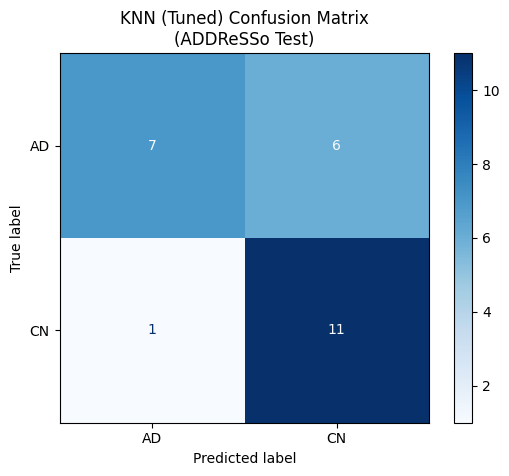


  Evaluating: KNN (Tuned) | Dataset: WLS External
Accuracy:    0.5250
Precision:   0.5714
Sensitivity: 0.2000
Specificity: 0.2000
F1-Score:    0.2963
ROC-AUC:     0.6013

Classification Report:
              precision    recall  f1-score   support

          AD       0.57      0.20      0.30        20
          CN       0.52      0.85      0.64        20

    accuracy                           0.53        40
   macro avg       0.54      0.53      0.47        40
weighted avg       0.54      0.53      0.47        40

------------------------------------------------------------


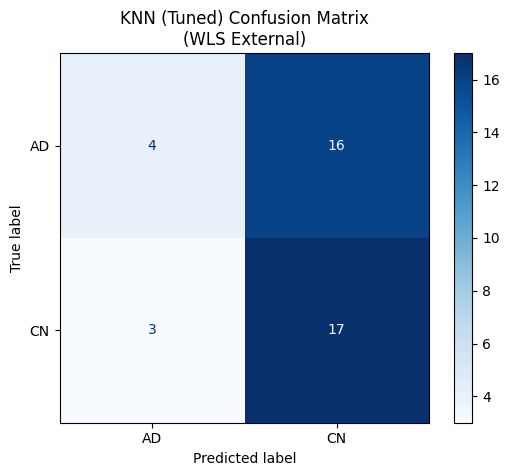

Tuning Neural Network (MLP)...
  Best Params: {'hidden_layer_sizes': (64,), 'alpha': 0.0001}

  Evaluating: Neural Network (MLP) (Tuned) | Dataset: ADDReSSo Val
Accuracy:    0.7083
Precision:   0.8000
Sensitivity: 0.6154
Specificity: 0.6154
F1-Score:    0.6957
ROC-AUC:     0.8741

Classification Report:
              precision    recall  f1-score   support

          AD       0.80      0.62      0.70        13
          CN       0.64      0.82      0.72        11

    accuracy                           0.71        24
   macro avg       0.72      0.72      0.71        24
weighted avg       0.73      0.71      0.71        24

------------------------------------------------------------


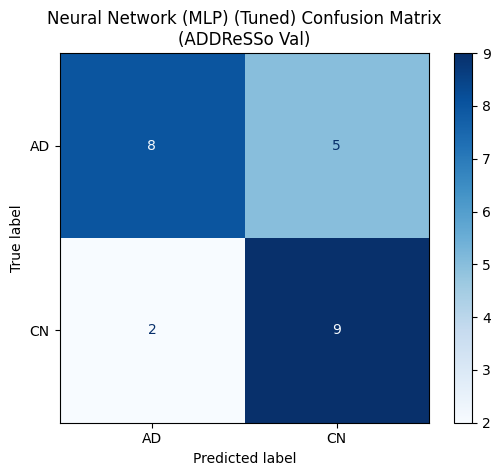


  Evaluating: Neural Network (MLP) (Tuned) | Dataset: ADDReSSo Test
Accuracy:    0.8000
Precision:   0.9000
Sensitivity: 0.6923
Specificity: 0.6923
F1-Score:    0.7826
ROC-AUC:     0.8782

Classification Report:
              precision    recall  f1-score   support

          AD       0.90      0.69      0.78        13
          CN       0.73      0.92      0.81        12

    accuracy                           0.80        25
   macro avg       0.82      0.80      0.80        25
weighted avg       0.82      0.80      0.80        25

------------------------------------------------------------


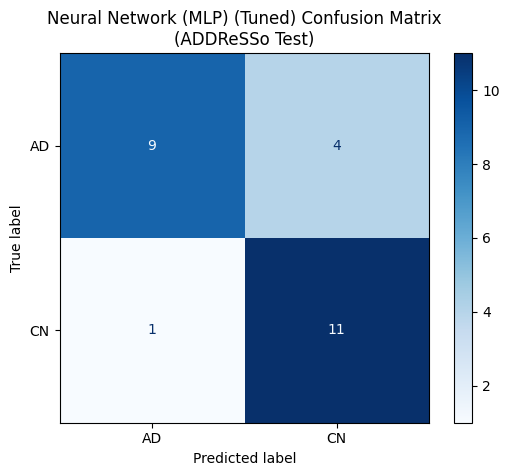


  Evaluating: Neural Network (MLP) (Tuned) | Dataset: WLS External
Accuracy:    0.5750
Precision:   0.6364
Sensitivity: 0.3500
Specificity: 0.3500
F1-Score:    0.4516
ROC-AUC:     0.5375

Classification Report:
              precision    recall  f1-score   support

          AD       0.64      0.35      0.45        20
          CN       0.55      0.80      0.65        20

    accuracy                           0.57        40
   macro avg       0.59      0.57      0.55        40
weighted avg       0.59      0.57      0.55        40

------------------------------------------------------------


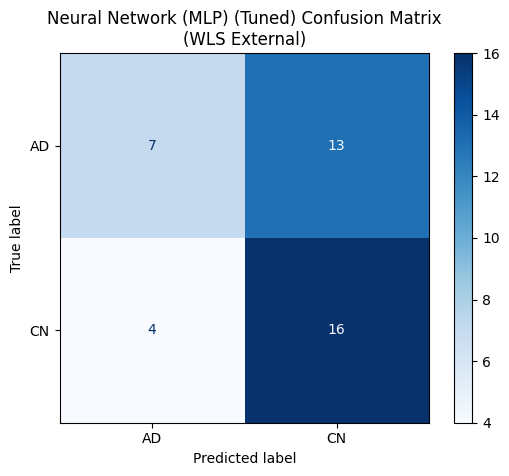

In [24]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# 1. Define the base models
models = {
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "KNN": KNeighborsClassifier(),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

# 2. Define search grids tailored for sparse text data
param_grids = {
    "SVM": {
        'kernel': ['linear', 'rbf'],         # Linear kernel is often superior for TF-IDF text
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    },
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced'],
        'solver': ['lbfgs', 'liblinear']     # liblinear handles small, sparse text datasets well
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],     # Slightly deeper trees allowed here vs audio
        'min_samples_split': [2, 5, 10]
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },
    "LightGBM": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 50]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    },
    "Neural Network (MLP)": {
        'hidden_layer_sizes': [(128, 64), (64, 32), (64,)], # Test simpler architectures
        'alpha': [0.0001, 0.001, 0.01]
    }
}

print("--- Commencing Hyperparameter Tuning for Linguistic Models ---")
print("Note: Running cross-validation. This will take a few minutes...\n")

best_linguistic_models = {}

# Iterate through the suite of models
for name, base_model in models.items():
    print(f"Tuning {name}...")

    # Setup the Randomized Search
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grids[name],
        n_iter=10,
        cv=5,
        scoring='accuracy',
        n_jobs=-1, # Utilize all available CPU cores
        random_state=42
    )

    # 1. Train and Tune using the ENCODED labels
    search.fit(X_train_text, y_train_encoded)

    # Extract the absolute best version of the model
    best_model = search.best_estimator_
    best_linguistic_models[name] = best_model

    print(f"  Best Params: {search.best_params_}")

    # Bundle our evaluation sets to loop through them cleanly
    eval_sets = [
        ("ADDReSSo Val", X_val_text, y_val),
        ("ADDReSSo Test", X_test_text, y_test),
        ("WLS External", X_wls_text, y_wls)
    ]

    for dataset_name, X_eval, y_eval in eval_sets:
        # 2. Predict using the tuned model
        y_pred_encoded = best_model.predict(X_eval)

        # 3. Decode predictions back to 'AD' and 'CN'
        y_pred = le.inverse_transform(y_pred_encoded)

        # 4. Get probability for ROC-AUC
        # Because we explicitly mapped AD to 1, the probability of AD is now safely at index 1
        y_proba = best_model.predict_proba(X_eval)[:, 1] if hasattr(best_model, "predict_proba") else None

        # 5. Evaluate using the updated function
        metrics = evaluate_clinical_model(f"{name} (Tuned)", dataset_name, y_eval, y_pred, y_proba, pos_label='AD')

        # Tag whether this was Acoustic or Linguistic
        metrics['Feature_Type'] = 'Linguistic'

        # Add to our master list
        global_summary_metrics.append(metrics)

## Generate the Summary Tables

In [ ]:
from IPython.display import display

print("=== FINAL MODEL SUMMARY TABLES ===")

# Convert the list of dictionaries into a Pandas DataFrame
df_results = pd.DataFrame(global_summary_metrics)

def show_summary_table(feature_type, dataset):
    print(f"\n--- {feature_type} Features: {dataset} ---")

    # Filter for the specific table we want
    df_filtered = df_results[(df_results['Feature_Type'] == feature_type) & (df_results['Dataset'] == dataset)]

    if df_filtered.empty:
        print("No data recorded for this slice yet.")
        return

    # Drop the tracking columns since we already know what table we are looking at
    df_display = df_filtered.drop(columns=['Feature_Type', 'Dataset']).set_index('Model')

    # Round to 2 decimal places
    df_display = df_display.round(2)

    display(df_display)

# Display the 4 specific tables
show_summary_table("Acoustic", "ADDReSSo Test")
show_summary_table("Acoustic", "WLS External")
show_summary_table("Linguistic", "ADDReSSo Test")
show_summary_table("Linguistic", "WLS External")

=== FINAL MODEL SUMMARY TABLES ===

--- Acoustic Features: ADDReSSo Test ---


,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
Model,,,,,,
SVM,0.60,0.57,0.92,0.92,0.71,0.57
Logistic Regression,0.52,0.53,0.69,0.69,0.60,0.62
Random Forest,0.56,0.56,0.69,0.69,0.62,0.48
Gradient Boosting,0.48,0.50,0.54,0.54,0.52,0.47
XGBoost,0.48,0.50,0.46,0.46,0.48,0.49
LightGBM,0.52,0.53,0.62,0.62,0.57,0.49
KNN,0.56,0.57,0.62,0.62,0.59,0.59
Neural Network (MLP),0.68,0.65,0.85,0.85,0.73,0.76
SVM (Tuned),0.60,0.57,0.92,0.92,0.71,0.57



--- Acoustic Features: WLS External ---


,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
Model,,,,,,
SVM,0.50,0.50,1.00,1.00,0.67,0.60
Logistic Regression,0.50,0.50,0.70,0.70,0.58,0.54
Random Forest,0.42,0.46,0.85,0.85,0.60,0.50
Gradient Boosting,0.52,0.51,0.90,0.90,0.65,0.52
XGBoost,0.57,0.55,0.90,0.90,0.68,0.49
LightGBM,0.52,0.51,0.90,0.90,0.65,0.63
KNN,0.42,0.45,0.75,0.75,0.57,0.41
Neural Network (MLP),0.60,0.60,0.60,0.60,0.60,0.60
SVM (Tuned),0.50,0.50,1.00,1.00,0.67,0.60



--- Linguistic Features: ADDReSSo Test ---


,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
Model,,,,,,
SVM,0.80,0.90,0.69,0.69,0.78,0.86
Logistic Regression,0.72,0.75,0.69,0.69,0.72,0.84
Random Forest,0.84,0.91,0.77,0.77,0.83,0.83
Gradient Boosting,0.64,0.70,0.54,0.54,0.61,0.68
XGBoost,0.64,0.67,0.62,0.62,0.64,0.74
LightGBM,0.64,0.64,0.69,0.69,0.67,0.78
KNN,0.76,1.00,0.54,0.54,0.70,0.86
Neural Network (MLP),0.80,0.90,0.69,0.69,0.78,0.87
SVM (Tuned),0.80,0.83,0.77,0.77,0.80,0.89



--- Linguistic Features: WLS External ---


,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
Model,,,,,,
SVM,0.55,0.55,0.55,0.55,0.55,0.54
Logistic Regression,0.57,0.57,0.65,0.65,0.60,0.55
Random Forest,0.60,0.67,0.40,0.40,0.50,0.58
Gradient Boosting,0.45,0.45,0.45,0.45,0.45,0.56
XGBoost,0.55,0.55,0.55,0.55,0.55,0.55
LightGBM,0.57,0.60,0.45,0.45,0.51,0.48
KNN,0.57,0.71,0.25,0.25,0.37,0.59
Neural Network (MLP),0.55,0.58,0.35,0.35,0.44,0.55
SVM (Tuned),0.52,0.53,0.40,0.40,0.46,0.57
